Compute mean connectivity from HCP7T dataset

In [300]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [301]:
tian_scale = 'S2'

lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-prefrontal',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-prefrontal_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])

In [302]:
region_list[8:13]

['L-HG', 'L-PP', 'L-PT', 'L-STGa', 'L-STGp']

In [303]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')

## Read in participant connectivity matrices

In [304]:
print(data_dir + 
      '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv')

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1//*/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv


In [305]:
conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         f'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv'))

# derive participant IDs directly from conn_files (preserves same order)
participants_with_files = sorted(list({os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files}))


In [306]:
print(len(conn_files))

96


In [307]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


          0         1         2         3         4         5         6   \
0   0.830017  0.339446  0.308448  0.142736  0.007415  0.011261  0.003171   
1   0.339446  0.424302  0.044860  0.195487  0.007700  0.020397  0.001533   
2   0.308448  0.044860  1.802076  0.395271  0.009352  0.002107  0.006522   
3   0.142736  0.195487  0.395271  1.048831  0.005213  0.015237  0.005610   
4   0.007415  0.007700  0.009352  0.005213  1.032988  0.311554  0.456820   
5   0.011261  0.020397  0.002107  0.015237  0.311554  0.502170  0.051837   
6   0.003171  0.001533  0.006522  0.005610  0.456820  0.051837  2.083032   
7   0.004873  0.003831  0.005173  0.019199  0.042357  0.192223  1.291996   
8   0.008635  0.411520  0.000759  0.004211  0.000037  0.000082  0.000000   
9   0.064614  0.522822  0.004643  0.007629  0.002060  0.002992  0.000374   
10  0.026864  0.110096  0.003433  0.008276  0.000000  0.000533  0.000109   
11  0.001250  0.029598  0.000199  0.000871  0.000000  0.000000  0.000000   
12  0.006314

In [308]:
conn_files_54 = [f for f in conn_files
                 if pd.read_csv(f, header=None).shape[0] == num_regions]

num_subjects = len(conn_files_54)
connmats_raw = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []

for sx, matrix_fpath in enumerate(conn_files_54):
    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    connmats_raw[sx,:,:] = sub_df.to_numpy()
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0)

In [309]:
# compute ROI volumes from MNI-space atlas
atlas_img = nib.load('/Users/dsj3886/data_local/derivatives/'
                     'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal/'
                     'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_atlas_space-MNI152NLin6Asym.nii.gz')
atlas_data = atlas_img.get_fdata()
vox_vol_mm3 = np.prod(atlas_img.header.get_zooms()[:3])

roi_volumes = np.array([
    np.sum(atlas_data == (i + 1)) * vox_vol_mm3
    for i in range(len(region_list))
])

# correct cortical columns for volume; leave striatal columns as-is
correction = np.ones(len(region_list))
cortical_mask = np.array([r.startswith(('L-', 'R-')) for r in region_list])
correction[cortical_mask] = roi_volumes[cortical_mask]

connmats_corrected = connmats_raw * correction[np.newaxis, np.newaxis, :]

In [310]:
connmats = connmats_corrected

In [311]:
np.shape(connmats)

(76, 54, 54)

In [312]:
# check the streamline count matrix (region x subject)
slcounts

array([[2.9932656 , 3.13960188, 3.41811002, ..., 3.2797443 , 2.67507724,
        2.45778141],
       [3.72346354, 4.05369161, 4.39118278, ..., 4.5265553 , 2.59177282,
        3.44055332],
       [3.0203204 , 1.43889476, 1.88506606, ..., 3.03443287, 3.98565649,
        2.10554823],
       ...,
       [6.07374233, 6.60754372, 5.12989893, ..., 6.183805  , 4.74643613,
        5.8193794 ],
       [1.89487069, 3.14537961, 3.07099755, ..., 3.05755014, 2.2295061 ,
        2.52108705],
       [4.15566367, 3.63534291, 3.50998061, ..., 3.88627623, 3.2312409 ,
        3.82539085]])

In [313]:
slcounts[0,:]

array([2.9932656 , 3.13960188, 3.41811002, 4.06843949, 2.66418241,
       2.70541147, 2.64848438, 3.70410158, 2.49805901, 3.99966765,
       3.25666959, 4.5690425 , 2.12417317, 3.22092497, 3.04684179,
       3.95493621, 4.77506281, 0.90540128, 3.01603489, 3.94656244,
       1.91750357, 3.58415546, 2.75201879, 2.80465874, 2.93342102,
       3.34101828, 3.45236009, 4.21083898, 3.6203336 , 3.81162772,
       2.15098174, 3.06014453, 3.16476663, 3.09205826, 1.7043181 ,
       3.047284  , 3.22565096, 2.40021402, 3.2162744 , 3.01228185,
       2.81211847, 2.70279909, 2.3343921 , 2.72354959, 3.09849475,
       2.44154731, 2.63256083, 3.12678451, 3.33854353, 4.58107519,
       2.38302749, 2.65610889, 3.84932627, 3.41907434, 2.39107423,
       2.09346414, 4.31258834, 2.82452864, 3.09731742, 2.85427869,
       2.98054384, 3.25298129, 2.09334252, 2.82554866, 3.65964006,
       2.5105875 , 2.48880418, 2.557754  , 3.36417431, 3.38354348,
       2.08689421, 3.39658592, 5.61187868, 3.2797443 , 2.67507

## Compute mean streamline count per ROI

In [314]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[3.07176867 3.90512266 2.43259866 2.382941   2.54482587 3.8606661
 2.39721384 2.91022134 4.53654597 5.60424083 5.70991391 3.89884099
 3.78831572 4.97291114 4.82976218 5.56265432 2.34817579 4.34498714
 2.17840562 2.18441738 3.20056145 3.07850833 2.63838901 2.86879617
 2.65301602 3.0130813  3.25704308 2.91037712 4.0135459  4.67245028
 0.66655181 0.37409642 3.05556449 3.1245003  2.75616162 2.95645734
 2.37435564 2.48749623 5.25809177 4.33281925 3.2085971  3.7001312
 4.85269443 4.66138491 6.00840403 2.97043426 4.35340877 3.13225939
 3.48720815 4.5139247  4.87617505 5.95484811 2.33773453 3.62025585]
(54,)


In [315]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[5.20177353e-01 3.10592503e-01 2.51318787e-01 ... 1.23911154e-01
  2.56673725e-02 2.56171047e-02]
 [3.10592503e-01 5.09407704e-01 3.03975535e-02 ... 6.83999472e-02
  1.02983068e+00 2.31423028e+00]
 [2.51318787e-01 3.03975535e-02 1.08200987e+00 ... 3.52502601e-01
  7.12564965e-02 0.00000000e+00]
 ...
 [1.73073834e-05 9.55381396e-06 4.92360653e-05 ... 2.03532052e+04
  1.23630485e+01 9.66489188e+03]
 [2.22979710e-05 8.94642985e-04 6.19025301e-05 ... 7.68932991e+01
  8.73557967e+02 2.39574967e+03]
 [1.27212927e-06 1.14923217e-04 0.00000000e+00 ... 3.43619016e+03
  1.36948950e+02 3.07762313e+04]]
(54, 54)


In [316]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [317]:
mean_df

,mean_slcount,seed,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,3.071769,aPUT-lh,5.201774e-01,3.105925e-01,2.513188e-01,6.646050e-02,3.046398e-03,2.623554e-03,4.237239e-03,3.899375e-03,...,446.320288,5.526347,173.533404,0.018617,0.033666,0.598386,2.909976,0.123911,0.025667,0.025617
1,3.905123,pPUT-lh,3.105925e-01,5.094077e-01,3.039755e-02,1.723887e-01,2.435092e-03,6.636018e-03,1.749279e-03,5.342021e-03,...,573.780954,16.658486,2449.547991,5.178040,0.003432,3.237090,2.967111,0.068400,1.029831,2.314230
2,2.432599,aCAU-lh,2.513188e-01,3.039755e-02,1.082010e+00,4.354808e-01,3.653141e-03,1.923542e-03,1.951461e-02,9.476624e-03,...,21.023017,2.060501,0.006341,0.189617,0.009687,0.993657,0.692659,0.352503,0.071256,0.000000
3,2.382941,pCAU-lh,6.646050e-02,1.723887e-01,4.354808e-01,9.315227e-01,3.977043e-03,8.087975e-03,1.176115e-02,3.785369e-02,...,5.362737,1.376899,10.066603,0.815362,0.036654,0.224420,0.432106,0.000000,0.093512,0.003442
4,2.544826,aPUT-rh,3.046398e-03,2.435092e-03,3.653141e-03,3.977043e-03,6.836486e-01,3.362192e-01,2.079358e-01,4.989892e-02,...,1.004001,0.028249,0.003652,722.424607,190.984926,234.325968,61.439381,595.978357,3.878788,223.961475
5,3.860666,pPUT-rh,2.623554e-03,6.636018e-03,1.923542e-03,8.087975e-03,3.362192e-01,4.695717e-01,2.999536e-02,1.573599e-01,...,0.122461,2.151957,0.146472,4775.658594,471.856545,238.873971,124.090912,705.249404,8.882341,2456.553228
6,2.397214,aCAU-rh,4.237239e-03,1.749279e-03,1.951461e-02,1.176115e-02,2.079358e-01,2.999536e-02,1.021983e+00,7.036767e-01,...,0.187442,0.017405,0.003361,28.506687,4.427806,9.139212,7.870672,23.356257,0.543695,0.122490
7,2.910221,pCAU-rh,3.899375e-03,5.342021e-03,9.476624e-03,3.785369e-02,4.989892e-02,1.573599e-01,7.036767e-01,1.297726e+00,...,0.004299,0.028934,0.000000,195.126774,14.174286,3.721179,4.559194,3.229403,0.318212,4.995742
8,4.536546,L-HG,1.464873e-02,4.814301e-01,9.570262e-04,1.465646e-03,6.212222e-06,5.266562e-04,3.084519e-05,1.042177e-04,...,5.351136,2.282748,20.889123,3.628654,0.003714,0.715613,0.072837,0.005475,0.331747,0.026175
9,5.604241,L-PP,9.754778e-02,5.514356e-01,9.089188e-03,1.321498e-02,5.296636e-04,6.450748e-04,4.237654e-04,3.824183e-04,...,500.421435,15.397219,1388.215019,0.298787,0.000000,1.464703,0.278975,0.003680,0.313956,1.307394


In [318]:

# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_prefrontal')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity_scale-invnodevol_sub-thresh-1.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df.to_csv(out_fpath, sep='\t', index=False)


#### Threshold low/null values

In [319]:
# Check distribution of non-zero values to pick a threshold
numeric_cols = mean_df.select_dtypes(include='number').columns
values = mean_df[numeric_cols].values.flatten()
values = values[values > 0]
pd.Series(values).describe(percentiles=[.01, .05, .1, .25])


count    2.614000e+03
mean     7.681992e+02
std      3.971774e+03
min      1.458399e-07
1%       6.030601e-06
5%       7.173794e-04
10%      3.046961e-03
25%      4.940664e-02
50%      3.065252e+00
max      7.689526e+04
dtype: float64

In [320]:
threshold = 1.0  # adjust based on distribution
numeric_cols = mean_df.select_dtypes(include='number').columns
mean_df_thresh = mean_df.copy()
mean_df_thresh[numeric_cols] = mean_df_thresh[numeric_cols].where(
    mean_df_thresh[numeric_cols] >= threshold, other=0.0
)


In [321]:
# save the thresholded mean data
out_dir = os.path.join(data_dir, 'group_plots_prefrontal')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity_scale-invnodevol_thresh-1.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df_thresh.to_csv(out_fpath, sep='\t', index=False)

### Plot distributions

In [322]:
connmats.shape

(76, 54, 54)

<Axes: >

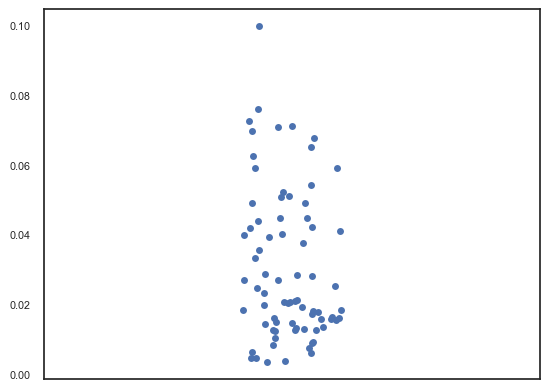

In [323]:
sns.stripplot(connmats[:,1,2])

## Connectivity plots

In [324]:
num_participants = len(connmats)
print('Number of participants:', num_participants)

Number of participants: 76


In [325]:
plot_df = mean_df_thresh.iloc[:, 2:]


In [326]:
plot_df

,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,L-HG,L-PP,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,37.085931,279.214418,...,446.320288,5.526347,173.533404,0.000000,0.000000,0.000000,2.909976,0.000000,0.000000,0.000000
1,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,1218.828301,1578.393497,...,573.780954,16.658486,2449.547991,5.178040,0.000000,3.237090,2.967111,0.000000,1.029831,2.314230
2,0.0,0.0,1.08201,0.0,0.0,0.0,0.000000,0.000000,2.422887,26.016301,...,21.023017,2.060501,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,3.710550,37.825712,...,5.362737,1.376899,10.066603,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.516075,...,1.004001,0.000000,0.000000,722.424607,190.984926,234.325968,61.439381,595.978357,3.878788,223.961475
5,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,1.333326,1.846420,...,0.000000,2.151957,0.000000,4775.658594,471.856545,238.873971,124.090912,705.249404,8.882341,2456.553228
6,0.0,0.0,0.00000,0.0,0.0,0.0,1.021983,0.000000,0.000000,1.212958,...,0.000000,0.000000,0.000000,28.506687,4.427806,9.139212,7.870672,23.356257,0.000000,0.000000
7,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,1.297726,0.000000,1.094609,...,0.000000,0.000000,0.000000,195.126774,14.174286,3.721179,4.559194,3.229403,0.000000,4.995742
8,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,4085.060302,2158.355233,...,5.351136,2.282748,20.889123,3.628654,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.0,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,1909.025761,4231.411488,...,500.421435,15.397219,1388.215019,0.000000,0.000000,1.464703,0.000000,0.000000,0.000000,1.307394


In [327]:
roi_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                       'atlas-custom_subcort-tians2_cort-aud-vis-prefrontal')

In [328]:
print(roi_dir)

/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal


In [329]:
cau_lh_list = sorted(glob(roi_dir+'/*CAU*lh.nii.gz'))
put_lh_list = sorted(glob(roi_dir+'/*PUT*lh.nii.gz'))
cau_rh_list = sorted(glob(roi_dir+'/*CAU*rh.nii.gz'))
put_rh_list = sorted(glob(roi_dir+'/*PUT*rh.nii.gz'))

cp_list = cau_lh_list + put_lh_list + cau_rh_list + put_rh_list

In [330]:
cp_list

['/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/deriva

In [331]:
cp_roi_list = [os.path.basename(x).split('.')[0].split('prefrontal_')[1] for x in cp_list]

print(cp_roi_list)


['aCAU-lh', 'pCAU-lh', 'aPUT-lh', 'pPUT-lh', 'aCAU-rh', 'pCAU-rh', 'aPUT-rh', 'pPUT-rh']


In [332]:
cp_sl_list = []
for rx, roi_name in enumerate(cp_roi_list):
    print(roi_name)
    roi_row = mean_df_thresh[mean_df_thresh.seed==roi_name]
    print(roi_row)

    roi_row_corrected = roi_row.iloc[0,2:].to_numpy() 
    print(roi_row_corrected)

    cp_sl_list.append(roi_row_corrected)

aCAU-lh
   mean_slcount     seed  aPUT-lh  pPUT-lh  aCAU-lh  pCAU-lh  aPUT-rh  \
2      2.432599  aCAU-lh      0.0      0.0  1.08201      0.0      0.0   

   pPUT-rh  aCAU-rh  pCAU-rh  ...   L-OccFus  L-SupraCalc  L-OccPole  \
2      0.0      0.0      0.0  ...  21.023017     2.060501        0.0   

   R-LOCsup  R-LOCinf  R-IntraCalc  R-TempOccFus  R-OccFus  R-SupraCalc  \
2       0.0       0.0          0.0           0.0       0.0          0.0   

   R-OccPole  
2        0.0  

[1 rows x 56 columns]
[0.0 0.0 1.082009869338583 0.0 0.0 0.0 0.0 0.0 2.422887035304497
 26.01630052448807 8.913254640312596 1.5848261706760005 1.4368987073319128
 0.0 1.1159887467428895 0.0 0.0 0.0 6271.588895670745 565.332427763937
 899.8572025386633 203.14004081065394 900.3574389170608 47.92487659341822
 563.118467592112 12.046243093744982 215.54420643286423 8.721722445435267
 103.19476473772711 6.092840610487931 235.86596051318386 13.0827337232782
 183.4801519163203 109.9412958799195 368.84715692078174 51.8416

In [333]:
cs_df = pd.DataFrame(data=cp_sl_list, 
                          columns=region_list,
                          index=cp_roi_list)
print(cs_df)

         aPUT-lh  pPUT-lh  aCAU-lh  pCAU-lh  aPUT-rh  pPUT-rh   aCAU-rh  \
aCAU-lh      0.0      0.0  1.08201      0.0      0.0      0.0  0.000000   
pCAU-lh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
aPUT-lh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
pPUT-lh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
aCAU-rh      0.0      0.0  0.00000      0.0      0.0      0.0  1.021983   
pCAU-rh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
aPUT-rh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   
pPUT-rh      0.0      0.0  0.00000      0.0      0.0      0.0  0.000000   

          pCAU-rh         L-HG         L-PP  ...    L-OccFus  L-SupraCalc  \
aCAU-lh  0.000000     2.422887    26.016301  ...   21.023017     2.060501   
pCAU-lh  0.000000     3.710550    37.825712  ...    5.362737     1.376899   
aPUT-lh  0.000000    37.085931   279.214418  ...  446.320288     5.526347   
pPUT-lh  0.00000

In [334]:
region_list

['aPUT-lh',
 'pPUT-lh',
 'aCAU-lh',
 'pCAU-lh',
 'aPUT-rh',
 'pPUT-rh',
 'aCAU-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp',
 'L-FP',
 'R-FP',
 'L-SFG',
 'R-SFG',
 'L-MFG',
 'R-MFG',
 'L-IFGt',
 'R-IFGt',
 'L-IFGo',
 'R-IFGo',
 'L-PreCG',
 'R-PreCG',
 'L-FMC',
 'R-FMC',
 'L-PCG',
 'R-PCG',
 'L-ACC',
 'R-ACC',
 'L-OFC',
 'R-OFC',
 'L-FO',
 'R-FO',
 'L-LOCsup',
 'L-LOCinf',
 'L-IntraCalc',
 'L-TempOccFus',
 'L-OccFus',
 'L-SupraCalc',
 'L-OccPole',
 'R-LOCsup',
 'R-LOCinf',
 'R-IntraCalc',
 'R-TempOccFus',
 'R-OccFus',
 'R-SupraCalc',
 'R-OccPole']

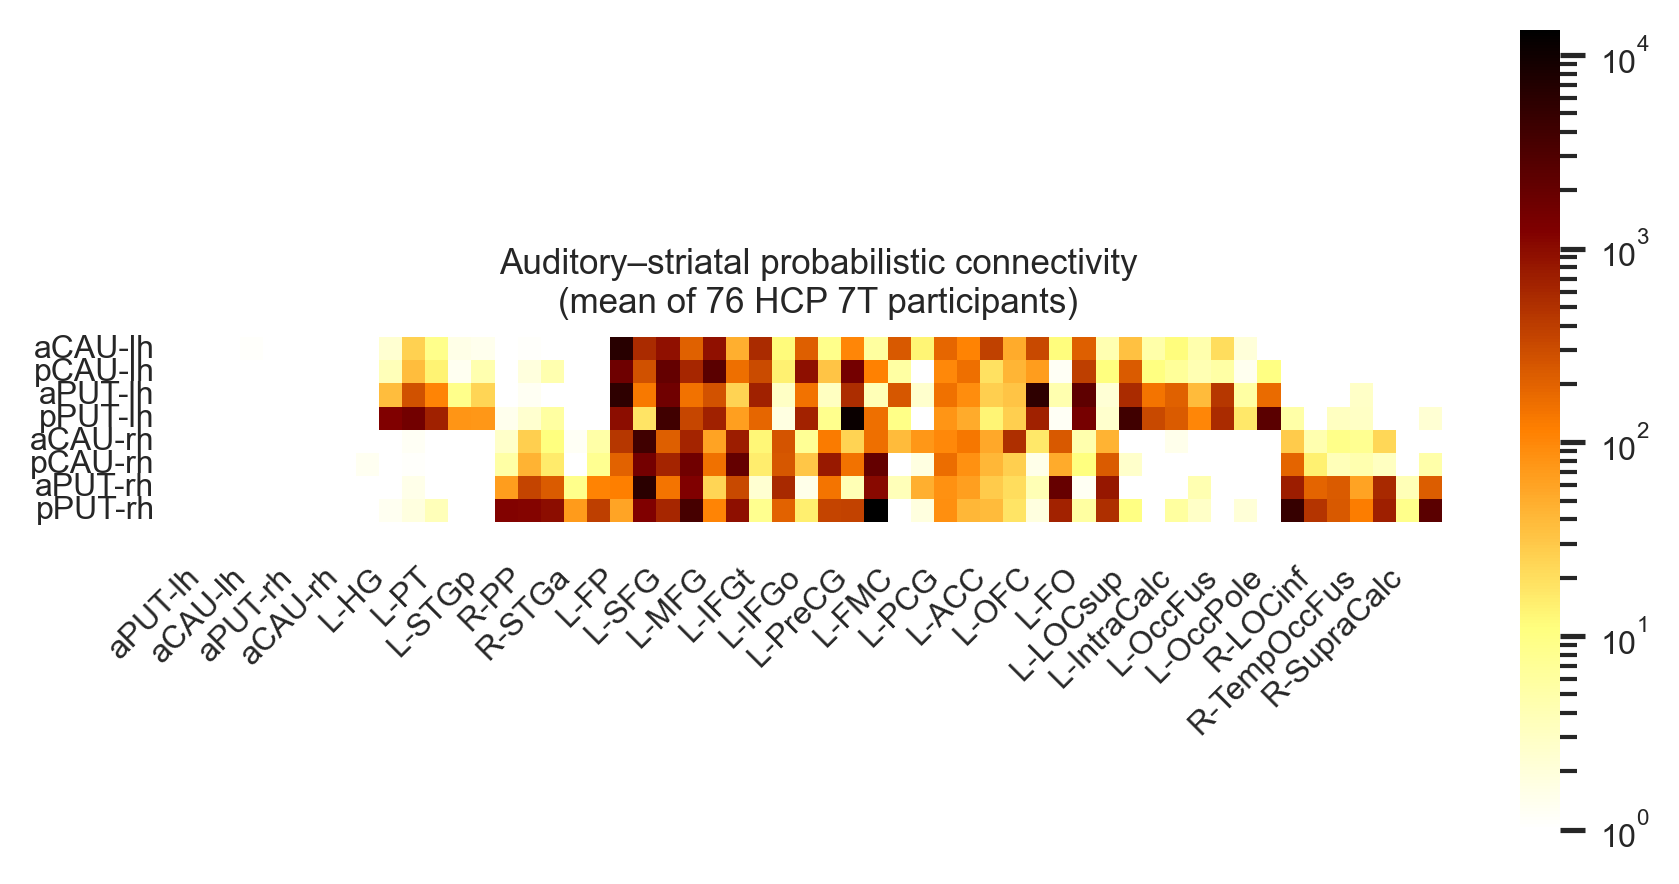

In [335]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

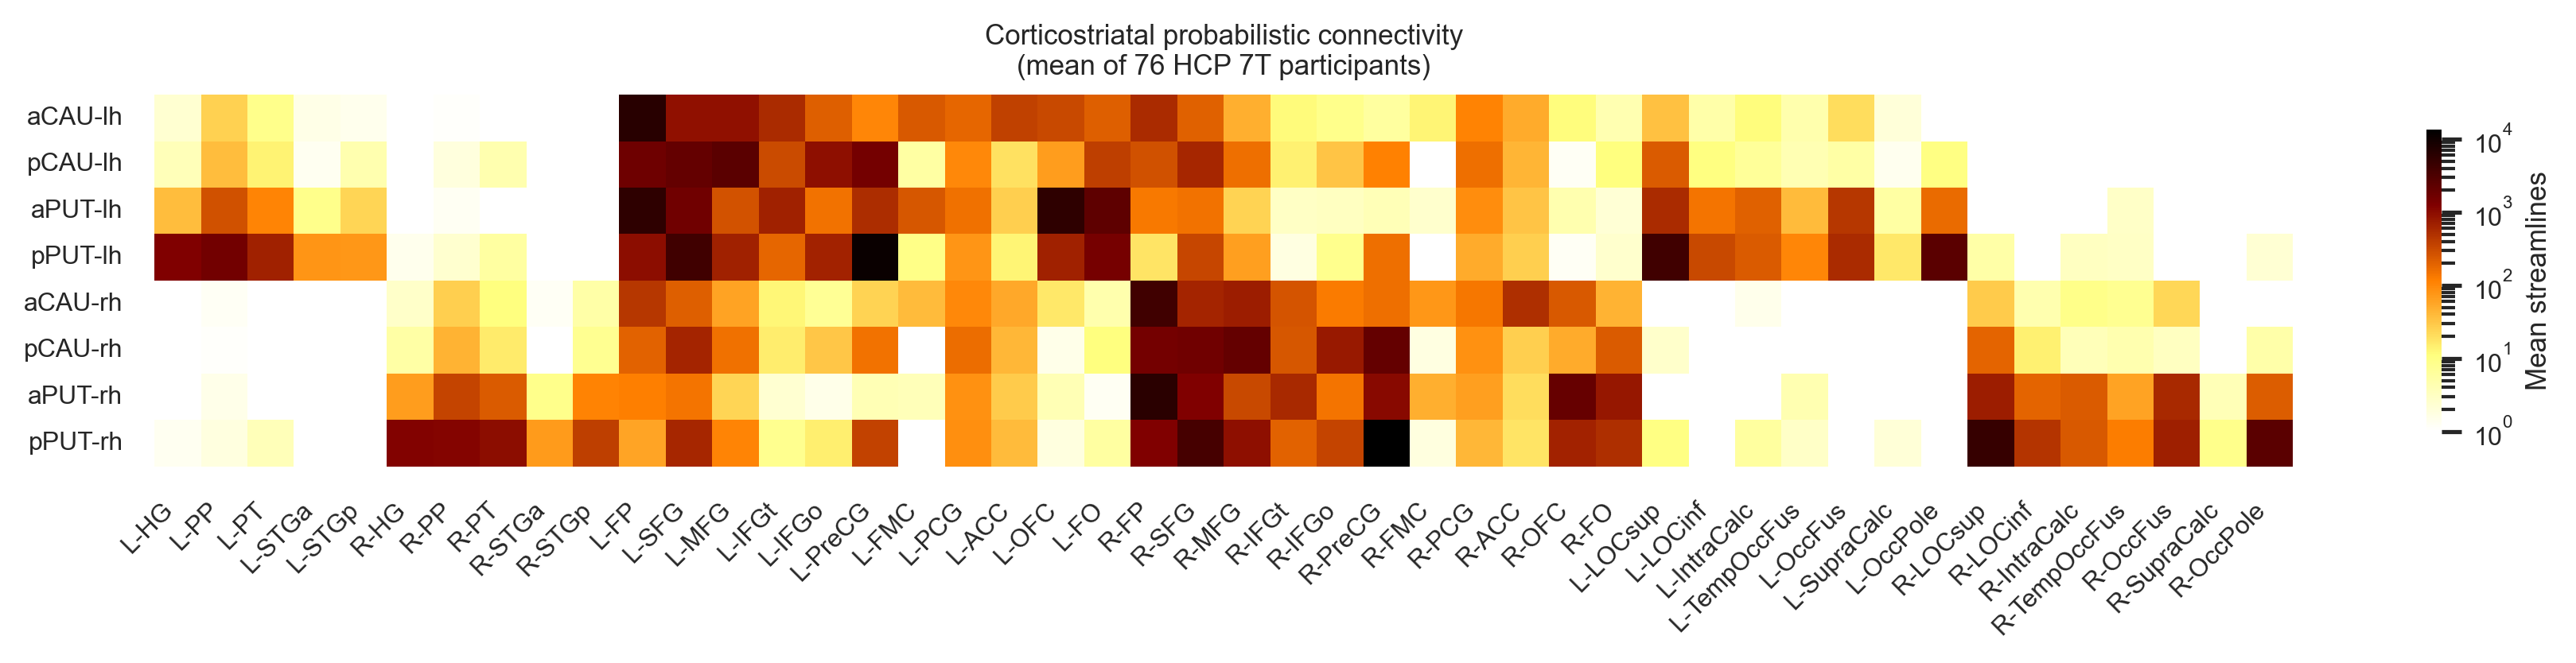

In [444]:
cortical_cols = [r for r in cs_df.columns if r.startswith(('L-', 'R-'))]

# Prefrontal ROIs were added with alternating L/R pairs; regroup to L-all then R-all
_pfc_base = {'FP', 'SFG', 'MFG', 'IFGt', 'IFGo', 'PreCG', 'FMC', 'PCG', 'ACC', 'OFC', 'FO'}
pfc_cols  = [c for c in cortical_cols if c[2:] in _pfc_base]
pfc_start = cortical_cols.index(pfc_cols[0])
pfc_end   = cortical_cols.index(pfc_cols[-1]) + 1

reordered = (cortical_cols[:pfc_start]
             + [c for c in pfc_cols if c.startswith('L-')]
             + [c for c in pfc_cols if c.startswith('R-')]
             + cortical_cols[pfc_end:])

cs_df_cortical = cs_df[reordered]

df_max = cs_df_cortical.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1, 1, figsize=(12, 3), dpi=300)

sns.heatmap(cs_df_cortical, ax=ax, cmap="afmhot_r",
            cbar_kws={'label': 'Mean streamlines', 'shrink': 0.5},
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Corticostriatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

f.savefig('heatmap_mean-streamlines_all-regions.svg')
f.tight_layout()


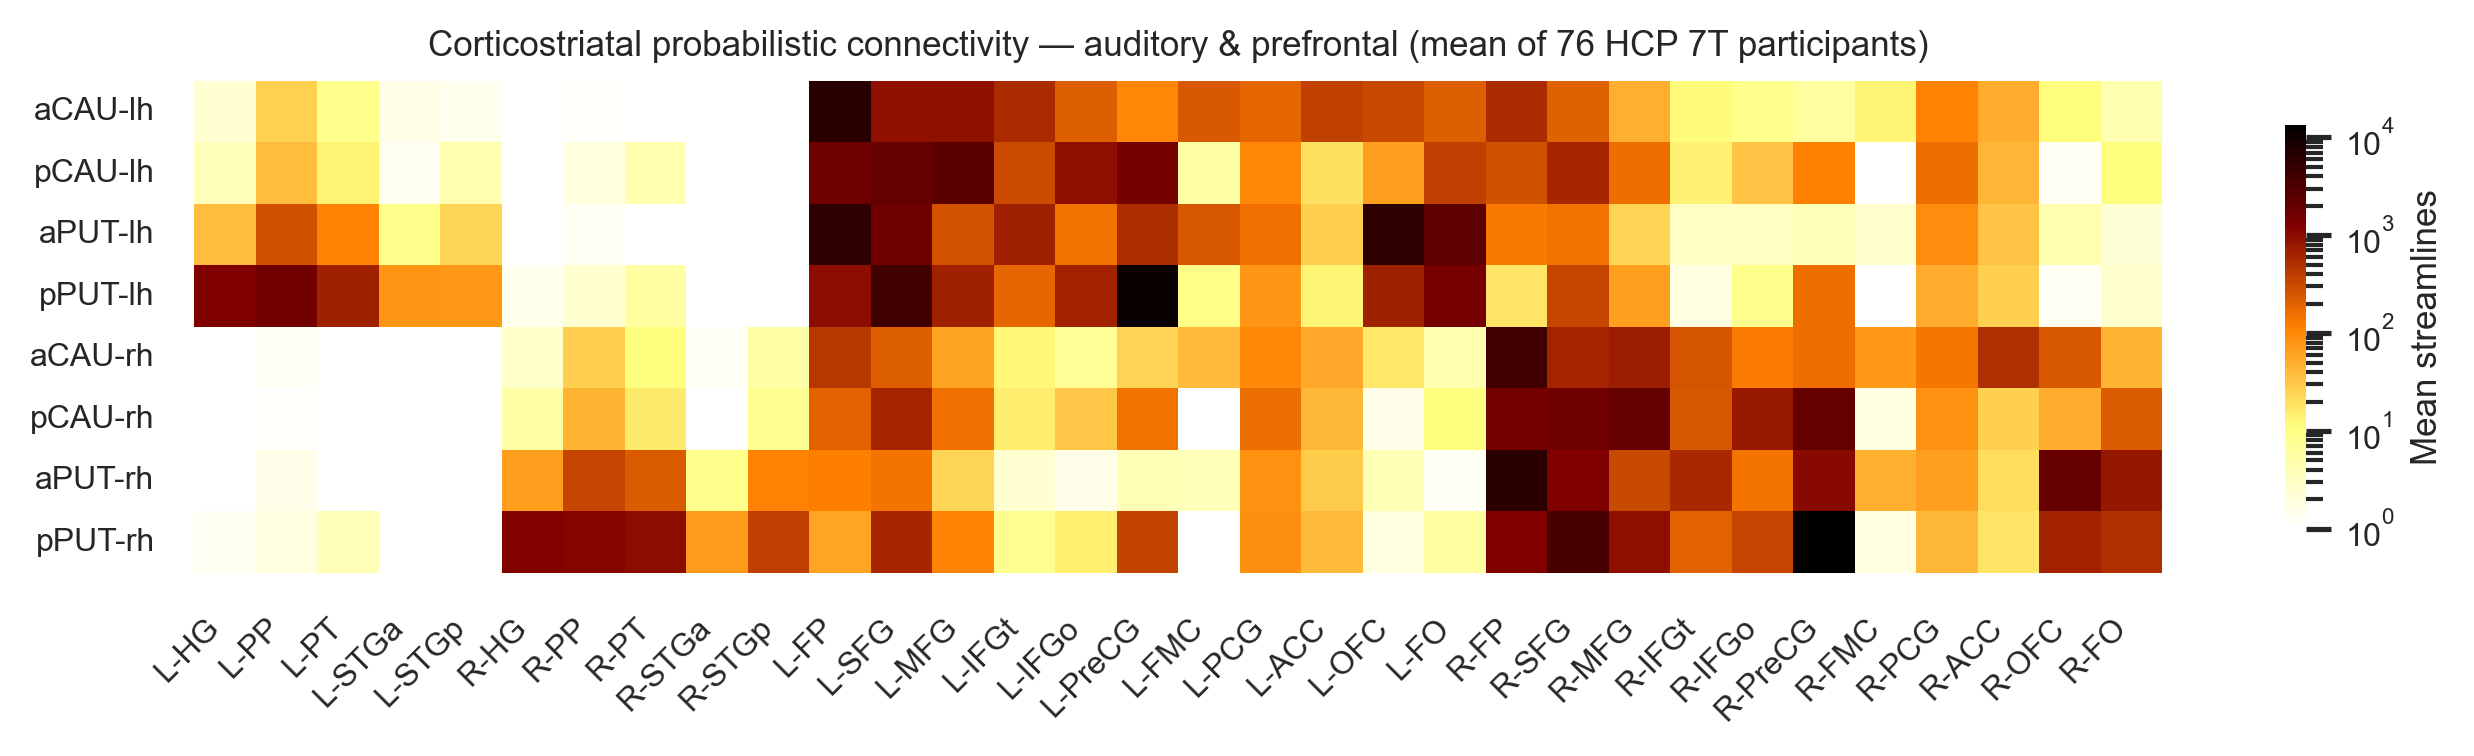

In [445]:
_aud_base = {'HG', 'PP', 'PT', 'STGa', 'STGp'}
no_vis_cols = [c for c in reordered if c[2:] in (_aud_base | _pfc_base)]
cs_df_no_vis = cs_df[no_vis_cols]

df_max_nov = cs_df_no_vis.to_numpy().max()

f2, ax2 = plt.subplots(1, 1, figsize=(9, 3), dpi=300)

sns.heatmap(cs_df_no_vis, ax=ax2, cmap="afmhot_r",
            cbar_kws={'label': 'Mean streamlines', 'shrink': 0.5},
            norm=colors.LogNorm(vmin=1, vmax=df_max_nov),
            square=True)
ax2.set_title(f'Corticostriatal probabilistic connectivity — auditory & prefrontal (mean of {num_participants} HCP 7T participants)')
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

f.savefig('heatmap_mean-streamlines_auditory-prefrontal-regions.svg')
f2.tight_layout()


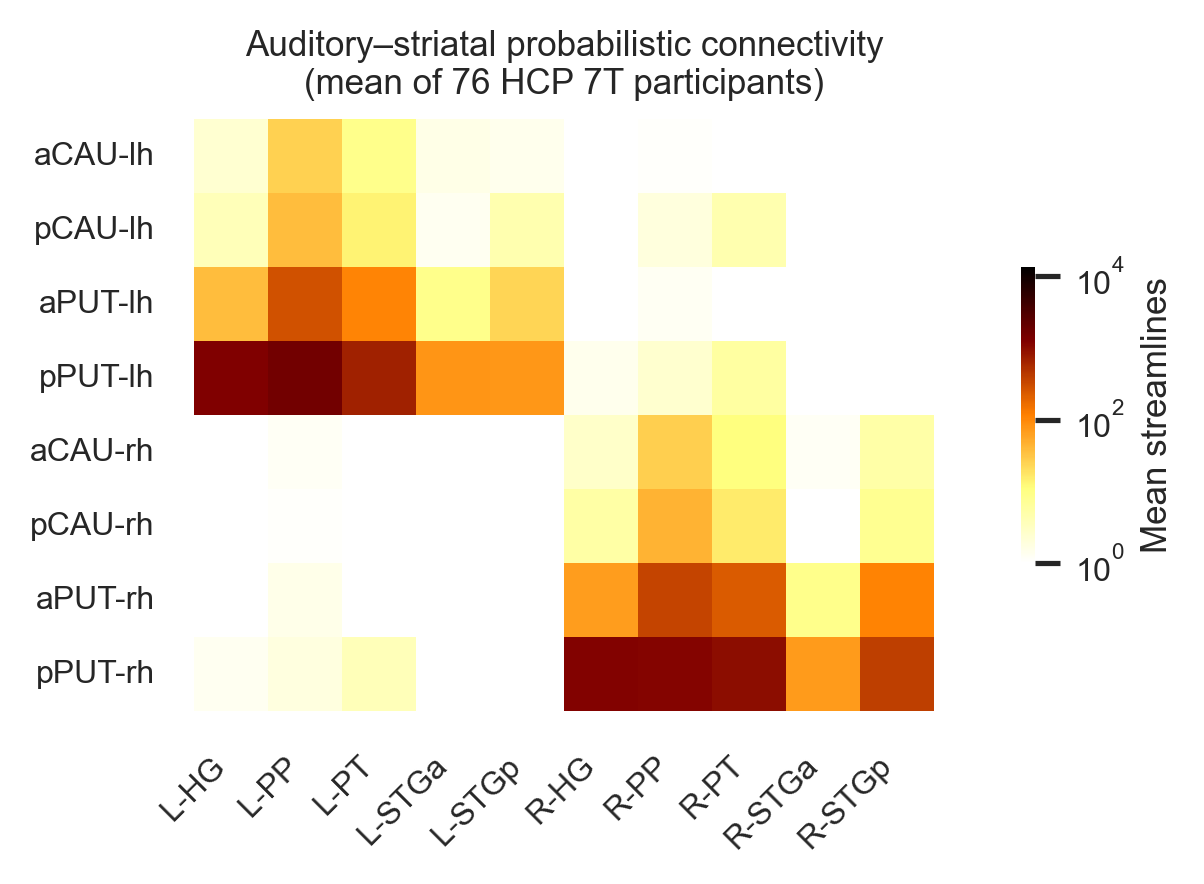

In [446]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df.iloc[:,8:18], ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            cbar_kws={'label': 'Mean streamlines', 'shrink': 0.5},
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');

f.savefig('heatmap_mean-streamlines_auditory-regions.svg')

f.tight_layout()

## Combine separate participants into single dataframe

In [339]:
participant_df_list = []
for i in range(connmats.shape[0]):
    df = pd.DataFrame(connmats[i], index=region_list, columns=region_list)
    df['participant_id'] = i
    participant_df_list.append(df)

In [340]:
striatum_rois = [r for r in region_list if r.startswith(('aPUT', 'pPUT', 'aCAU', 'pCAU'))]
cortex_rois = [r for r in region_list if r.startswith(('L-', 'R-'))]

filtered_df_list = []
for df in participant_df_list:
    sub_df = df.loc[striatum_rois, cortex_rois]
    sub_df['participant_id'] = df['participant_id'].iloc[0]
    filtered_df_list.append(sub_df)

In [341]:
rostral_caudal_map = {
    'aPUT-lh': 'Rostral', 'aCAU-lh': 'Rostral',
    'pPUT-lh': 'Caudal', 'pCAU-lh': 'Caudal',
    'aPUT-rh': 'Rostral', 'aCAU-rh': 'Rostral',
    'pPUT-rh': 'Caudal', 'pCAU-rh': 'Caudal'
}

for df in filtered_df_list:
    df['Rostral_Caudal'] = df.index.map(rostral_caudal_map)

In [342]:
caudate_putamen_map = {
    'aPUT-lh': 'Putamen', 'aCAU-lh': 'Caudate',
    'pPUT-lh': 'Putamen', 'pCAU-lh': 'Caudate',
    'aPUT-rh': 'Putamen', 'aCAU-rh': 'Caudate',
    'pPUT-rh': 'Putamen', 'pCAU-rh': 'Caudate'
}

for df in filtered_df_list:
    df['Caudate_Putamen'] = df.index.map(caudate_putamen_map)

In [343]:
all_df = pd.concat(filtered_df_list)
all_df = all_df.reset_index().rename(columns={'index': 'Striatum_ROI'})

In [344]:

# Melt to long format
all_long_df = all_df.melt(id_vars=['participant_id', 'Striatum_ROI', 'Rostral_Caudal', 'Caudate_Putamen'], 
                      value_vars=cortex_rois, 
                      var_name='Cortex_ROI', value_name='Connectivity')


In [345]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity
0,0,aPUT-lh,Rostral,Putamen,L-HG,21.862174
1,0,pPUT-lh,Caudal,Putamen,L-HG,1041.838055
2,0,aCAU-lh,Rostral,Caudate,L-HG,1.922404
3,0,pCAU-lh,Caudal,Caudate,L-HG,10.660441
4,0,aPUT-rh,Rostral,Putamen,L-HG,0.093693


In [346]:
# Add hemisphere info before stripping labels
def get_striatum_hemisphere(roi):
    if roi.endswith('-lh'):
        return 'Left'
    elif roi.endswith('-rh'):
        return 'Right'
    else:
        return None

def get_cortex_hemisphere(roi):
    if roi.startswith('L-'):
        return 'Left'
    elif roi.startswith('R-'):
        return 'Right'
    else:
        return None

all_long_df['striatum_hemisphere'] = all_long_df['Striatum_ROI'].apply(get_striatum_hemisphere)
all_long_df['cortex_hemisphere'] = all_long_df['Cortex_ROI'].apply(get_cortex_hemisphere)

# Keep only rows where hemispheres match
all_long_df = all_long_df[all_long_df['striatum_hemisphere'] == all_long_df['cortex_hemisphere']]

# Optionally, create a single 'hemisphere' column and strip hemisphere labels
all_long_df['hemisphere'] = all_long_df['striatum_hemisphere']
all_long_df['Striatum_ROI'] = all_long_df['Striatum_ROI'].apply(lambda x: x[:-3] if x.endswith(('-lh', '-rh')) else x)
all_long_df['Cortex_ROI'] = all_long_df['Cortex_ROI'].apply(lambda x: x[2:] if x.startswith(('L-', 'R-')) else x)

In [347]:
all_long_df.shape

(13984, 9)

In [348]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity,striatum_hemisphere,cortex_hemisphere,hemisphere
0,0,aPUT,Rostral,Putamen,HG,21.862174,Left,Left,Left
1,0,pPUT,Caudal,Putamen,HG,1041.838055,Left,Left,Left
2,0,aCAU,Rostral,Caudate,HG,1.922404,Left,Left,Left
3,0,pCAU,Caudal,Caudate,HG,10.660441,Left,Left,Left
8,1,aPUT,Rostral,Putamen,HG,25.605283,Left,Left,Left


In [349]:
all_long_df.Cortex_ROI.unique()

array(['HG', 'PP', 'PT', 'STGa', 'STGp', 'FP', 'SFG', 'MFG', 'IFGt',
       'IFGo', 'PreCG', 'FMC', 'PCG', 'ACC', 'OFC', 'FO', 'LOCsup',
       'LOCinf', 'IntraCalc', 'TempOccFus', 'OccFus', 'SupraCalc',
       'OccPole'], dtype=object)

In [350]:
auditory_rois = ['HG', 'PP', 'PT', 'STGp', 'STGa']
long_df = all_long_df[all_long_df['Cortex_ROI'].isin(auditory_rois)]


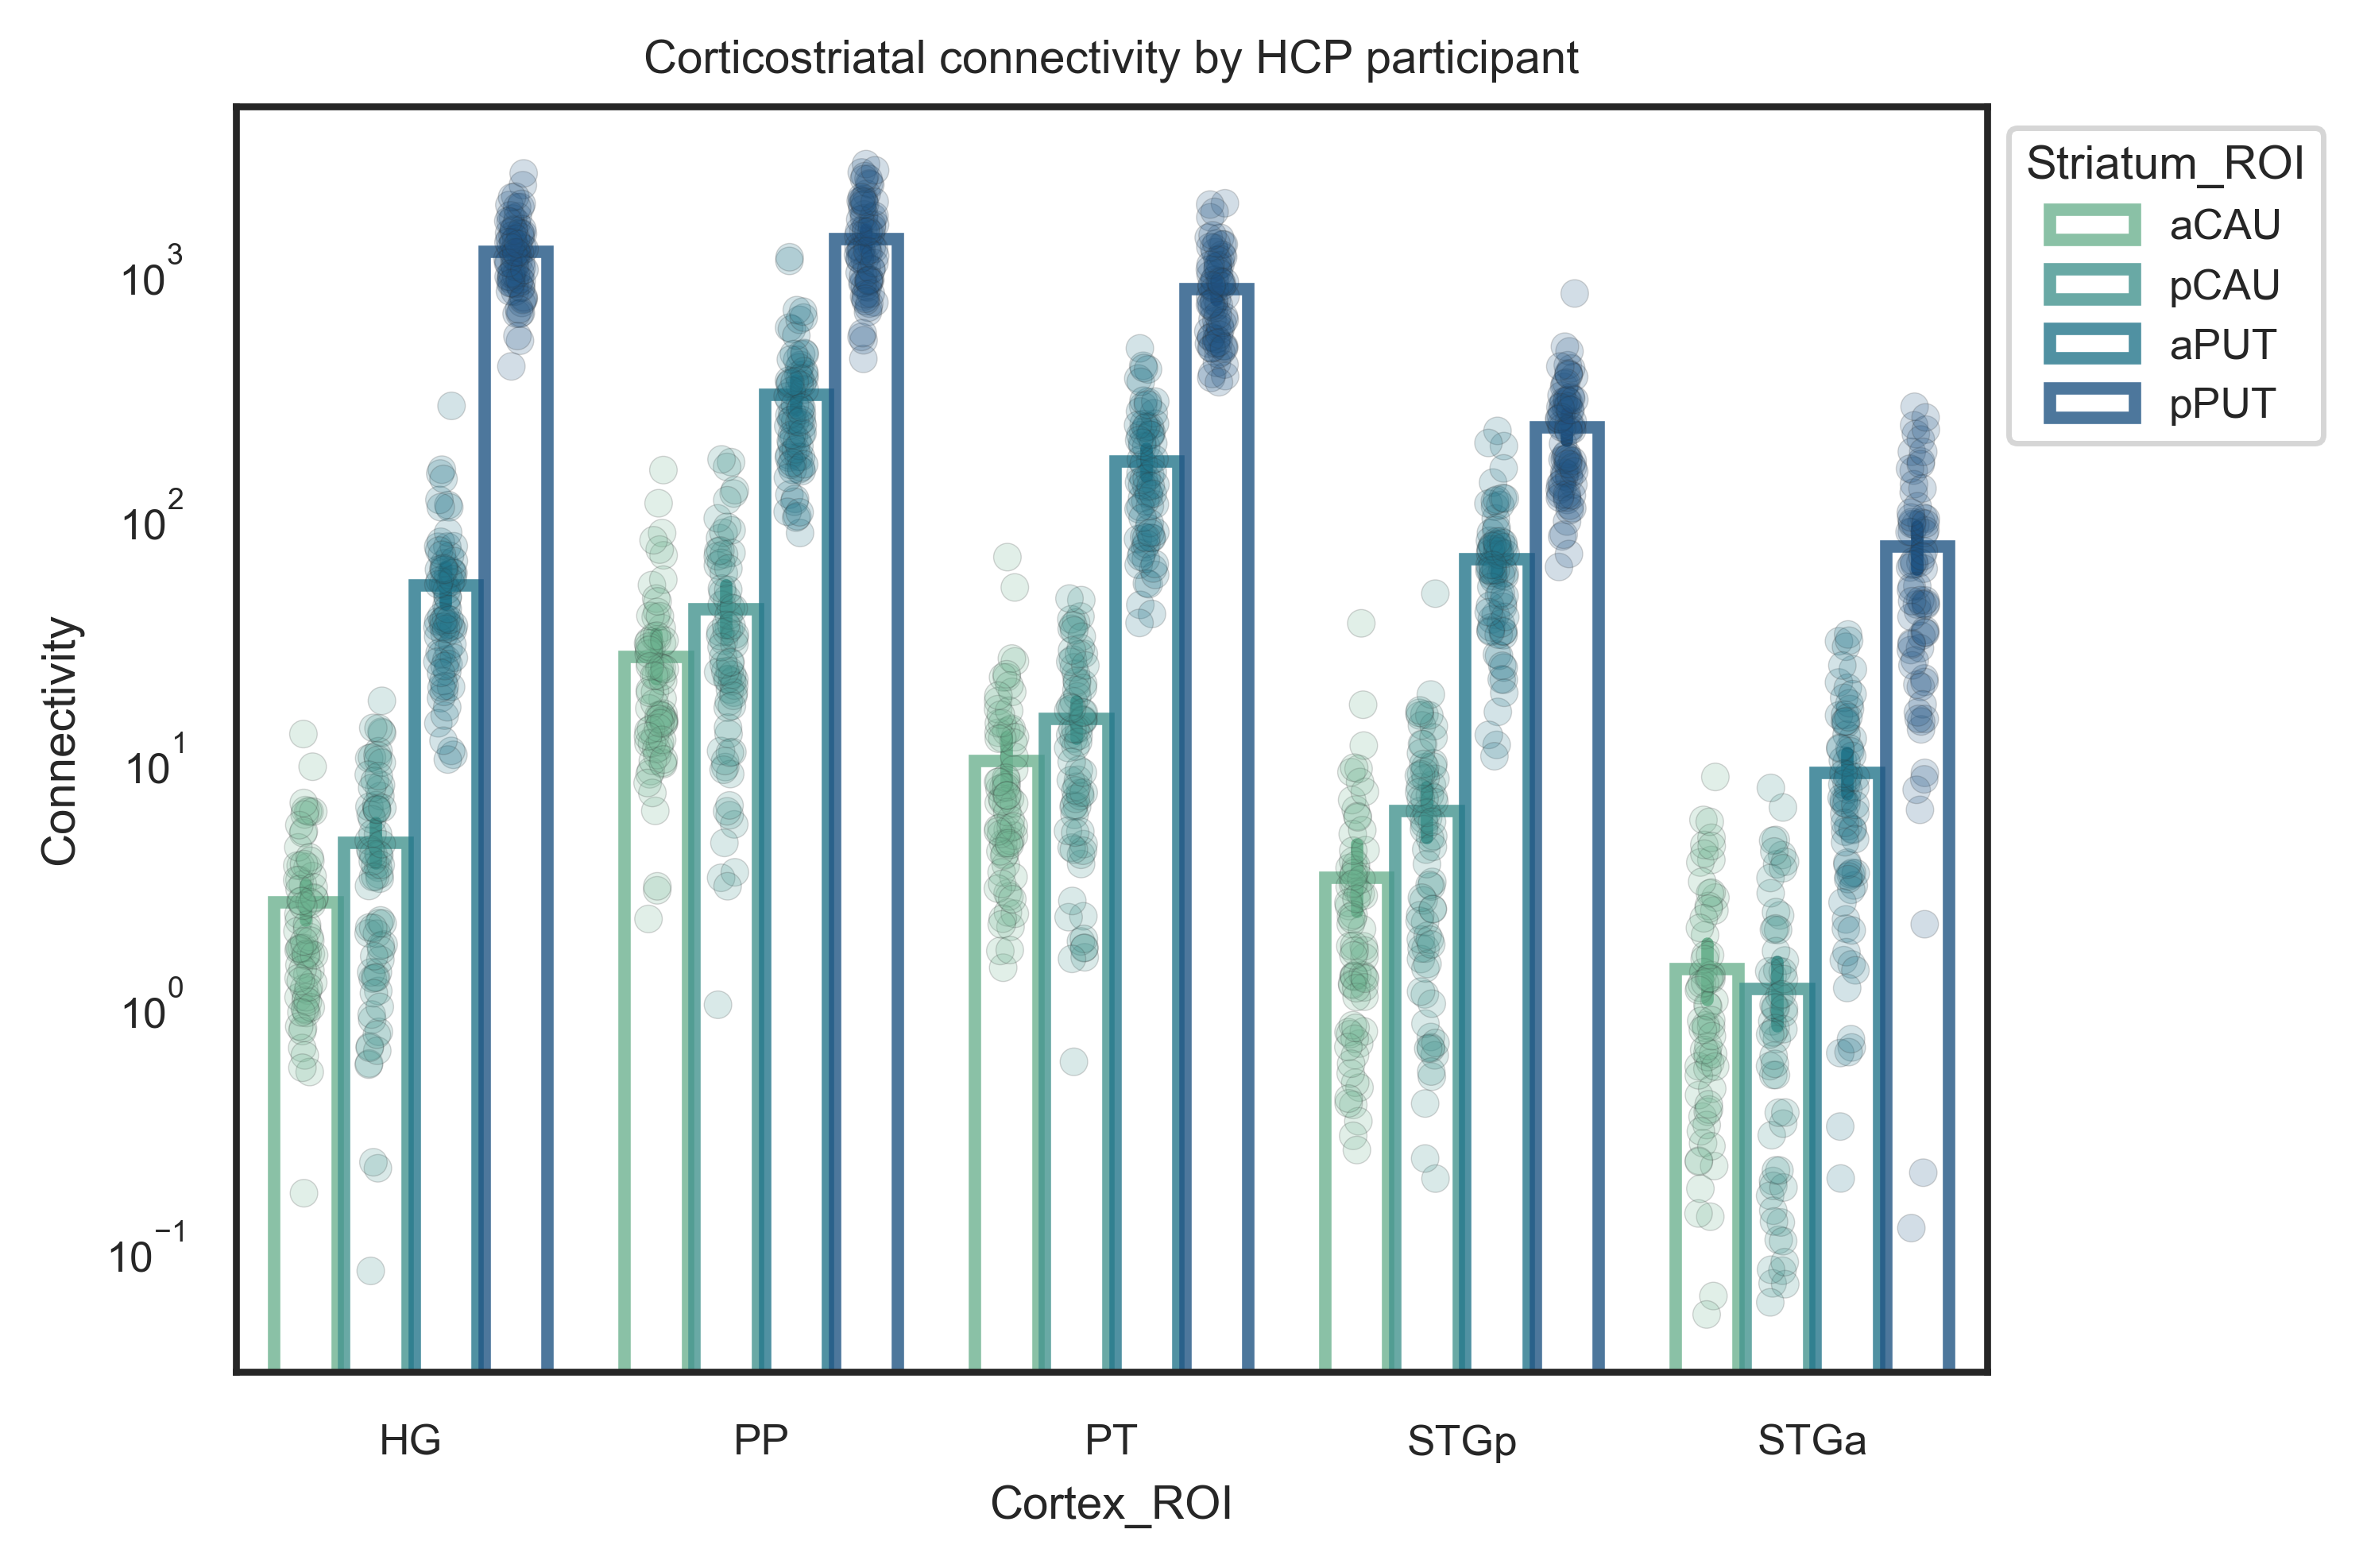

In [351]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Striatum_ROI',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=500)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.8, gap=0.1, fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.2,
              alpha=0.2,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()
fig.savefig('streamline-count_x-cortex_hue-striatum.svg')

## Across-participant statistics

In [352]:
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

### All factors

In [353]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,740.7798,1.0000,75.0000,0.0000
Rostral_Caudal,614.8950,1.0000,75.0000,0.0000
Cortex_ROI,331.4317,4.0000,300.0000,0.0000
hemisphere,6.7448,1.0000,75.0000,0.0113
Caudate_Putamen:Rostral_Caudal,613.5279,1.0000,75.0000,0.0000
Caudate_Putamen:Cortex_ROI,308.5566,4.0000,300.0000,0.0000
Rostral_Caudal:Cortex_ROI,220.5020,4.0000,300.0000,0.0000
Caudate_Putamen:hemisphere,6.1142,1.0000,75.0000,0.0157
Rostral_Caudal:hemisphere,1.1004,1.0000,75.0000,0.2976
Cortex_ROI:hemisphere,49.9672,4.0000,300.0000,0.0000


### No hemisphere

In [354]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,740.7798,1.0000,75.0000,0.0000
Rostral_Caudal,614.8950,1.0000,75.0000,0.0000
Cortex_ROI,331.4317,4.0000,300.0000,0.0000
Caudate_Putamen:Rostral_Caudal,613.5279,1.0000,75.0000,0.0000
Caudate_Putamen:Cortex_ROI,308.5566,4.0000,300.0000,0.0000
Rostral_Caudal:Cortex_ROI,220.5020,4.0000,300.0000,0.0000
Caudate_Putamen:Rostral_Caudal:Cortex_ROI,219.7923,4.0000,300.0000,0.0000


### Caudate–Putamen

In [355]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,740.7798,1.0000,75.0000,0.0000
Cortex_ROI,331.4317,4.0000,300.0000,0.0000
hemisphere,6.7448,1.0000,75.0000,0.0113
Caudate_Putamen:Cortex_ROI,308.5566,4.0000,300.0000,0.0000
Caudate_Putamen:hemisphere,6.1142,1.0000,75.0000,0.0157
Cortex_ROI:hemisphere,49.9672,4.0000,300.0000,0.0000
Caudate_Putamen:Cortex_ROI:hemisphere,55.0970,4.0000,300.0000,0.0000


In [356]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Caudate_Putamen', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,T,dof,p_unc,p_corr,BF10
0,Caudate_Putamen,-,Caudate,Putamen,-27.217270,75.0,1.300610e-40,NaN,1.565e+37
1,Cortex_ROI,-,HG,PP,-7.983099,75.0,1.284965e-11,1.427739e-11,6.945e+08
2,Cortex_ROI,-,HG,PT,5.342264,75.0,9.490934e-07,9.490934e-07,1.564e+04
3,Cortex_ROI,-,HG,STGa,24.328229,75.0,2.521094e-37,1.260547e-36,9.127e+33
4,Cortex_ROI,-,HG,STGp,19.104528,75.0,1.542922e-30,3.085844e-30,1.958e+27
5,Cortex_ROI,-,PP,PT,10.757955,75.0,7.355959e-17,9.194949e-17,8.257e+13
6,Cortex_ROI,-,PP,STGa,24.519564,75.0,1.494686e-37,1.260547e-36,1.526e+34
7,Cortex_ROI,-,PP,STGp,21.360978,75.0,1.287963e-33,4.293210e-33,2.066e+30
8,Cortex_ROI,-,PT,STGa,19.822149,75.0,1.525008e-31,3.812519e-31,1.899e+28
9,Cortex_ROI,-,PT,STGp,15.833748,75.0,1.264369e-25,2.107281e-25,2.978e+22


In [357]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Cortex_ROI', 'Caudate_Putamen', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


/Users/dsj3886/miniconda3/envs/py24/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7321: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-7.983099,75.0,1.284965e-11,1.427739e-11,6.945e+08
1,Cortex_ROI,-,HG,PT,5.342264,75.0,9.490934e-07,9.490934e-07,1.564e+04
2,Cortex_ROI,-,HG,STGa,24.328229,75.0,2.521094e-37,1.260547e-36,9.127e+33
3,Cortex_ROI,-,HG,STGp,19.104528,75.0,1.542922e-30,3.085844e-30,1.958e+27
4,Cortex_ROI,-,PP,PT,10.757955,75.0,7.355959e-17,9.194949e-17,8.257e+13
5,Cortex_ROI,-,PP,STGa,24.519564,75.0,1.494686e-37,1.260547e-36,1.526e+34
6,Cortex_ROI,-,PP,STGp,21.360978,75.0,1.287963e-33,4.293210e-33,2.066e+30
7,Cortex_ROI,-,PT,STGa,19.822149,75.0,1.525008e-31,3.812519e-31,1.899e+28
8,Cortex_ROI,-,PT,STGp,15.833748,75.0,1.264369e-25,2.107281e-25,2.978e+22
9,Cortex_ROI,-,STGa,STGp,-14.769301,75.0,6.685393e-24,9.550561e-24,6.124e+20


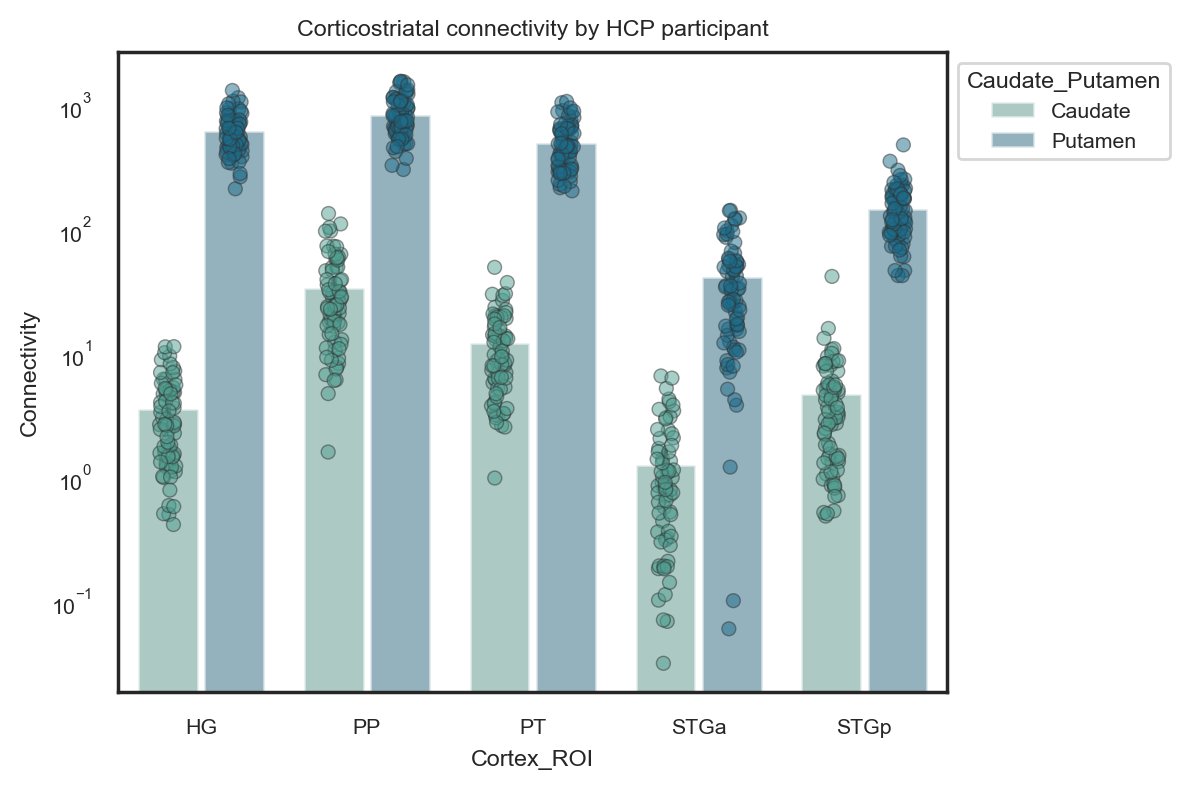

In [358]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=200)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.5, gap=0.1, #fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.5,
              alpha=0.5,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()


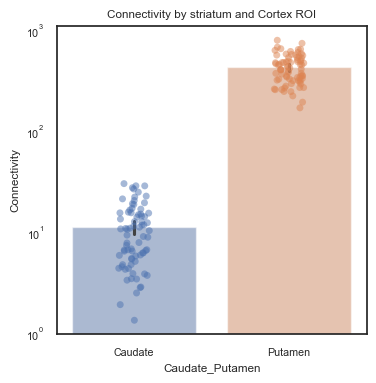

In [359]:
df_collapsed = long_df.groupby(["participant_id", 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(4, 4))
sns.barplot(x='Caudate_Putamen', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, alpha=0.5)
sns.stripplot(x='Caudate_Putamen', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, alpha=0.5)

plt.title('Connectivity by striatum and Cortex ROI')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

In [360]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


/Users/dsj3886/miniconda3/envs/py24/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7321: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere,-,Left,Right,-2.597068,75.0,1.131018e-02,NaN,2.868
1,Cortex_ROI,-,HG,PP,-7.983099,75.0,1.284965e-11,1.427739e-11,6.945e+08
2,Cortex_ROI,-,HG,PT,5.342264,75.0,9.490934e-07,9.490934e-07,1.564e+04
3,Cortex_ROI,-,HG,STGa,24.328229,75.0,2.521094e-37,1.260547e-36,9.127e+33
4,Cortex_ROI,-,HG,STGp,19.104528,75.0,1.542922e-30,3.085844e-30,1.958e+27
5,Cortex_ROI,-,PP,PT,10.757955,75.0,7.355959e-17,9.194949e-17,8.257e+13
6,Cortex_ROI,-,PP,STGa,24.519564,75.0,1.494686e-37,1.260547e-36,1.526e+34
7,Cortex_ROI,-,PP,STGp,21.360978,75.0,1.287963e-33,4.293210e-33,2.066e+30
8,Cortex_ROI,-,PT,STGa,19.822149,75.0,1.525008e-31,3.812519e-31,1.899e+28
9,Cortex_ROI,-,PT,STGp,15.833748,75.0,1.264369e-25,2.107281e-25,2.978e+22


In [361]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-7.983099,75.0,1.284965e-11,1.427739e-11,6.945e+08
1,Cortex_ROI,-,HG,PT,5.342264,75.0,9.490934e-07,9.490934e-07,1.564e+04
2,Cortex_ROI,-,HG,STGa,24.328229,75.0,2.521094e-37,1.260547e-36,9.127e+33
3,Cortex_ROI,-,HG,STGp,19.104528,75.0,1.542922e-30,3.085844e-30,1.958e+27
4,Cortex_ROI,-,PP,PT,10.757955,75.0,7.355959e-17,9.194949e-17,8.257e+13
5,Cortex_ROI,-,PP,STGa,24.519564,75.0,1.494686e-37,1.260547e-36,1.526e+34
6,Cortex_ROI,-,PP,STGp,21.360978,75.0,1.287963e-33,4.293210e-33,2.066e+30
7,Cortex_ROI,-,PT,STGa,19.822149,75.0,1.525008e-31,3.812519e-31,1.899e+28
8,Cortex_ROI,-,PT,STGp,15.833748,75.0,1.264369e-25,2.107281e-25,2.978e+22
9,Cortex_ROI,-,STGa,STGp,-14.769301,75.0,6.685393e-24,9.550561e-24,6.124e+20


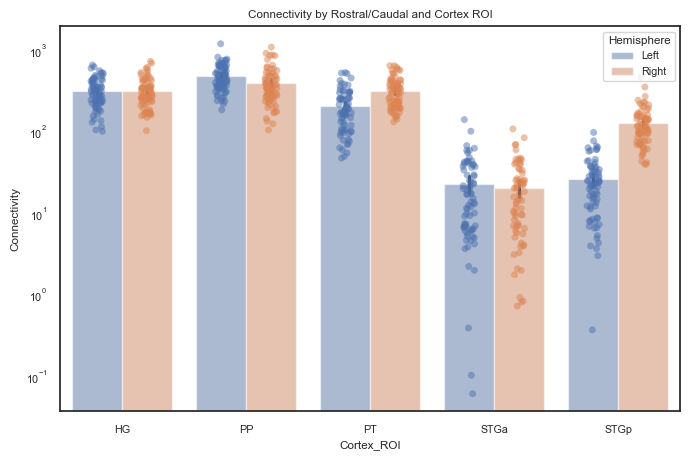

In [362]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [363]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise)

Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


/Users/dsj3886/miniconda3/envs/py24/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7321: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,Contrast,Striatum_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Striatum_ROI,-,aCAU,aPUT,-16.670575,75.0,6.177606e-27,9.266409e-27,5.734e+23
1,Striatum_ROI,-,aCAU,pCAU,-5.166962,75.0,1.902862e-06,1.902862e-06,8125.525
2,Striatum_ROI,-,aCAU,pPUT,-26.840700,75.0,3.359273e-40,1.229439e-39,6.15e+36
3,Striatum_ROI,-,aPUT,pCAU,15.354279,75.0,7.418905e-25,8.902687e-25,5.266e+21
4,Striatum_ROI,-,aPUT,pPUT,-24.800509,75.0,6.977138e-38,1.395428e-37,3.229e+34
5,Striatum_ROI,-,pCAU,pPUT,-26.762344,75.0,4.098129e-40,1.229439e-39,5.057e+36
6,hemisphere,-,Left,Right,-2.597068,75.0,1.131018e-02,NaN,2.868
7,Striatum_ROI * hemisphere,aCAU,Left,Right,-1.079367,75.0,2.838834e-01,3.684231e-01,0.221
8,Striatum_ROI * hemisphere,aPUT,Left,Right,-7.102354,75.0,5.967026e-10,2.386811e-09,1.739e+07
9,Striatum_ROI * hemisphere,pCAU,Left,Right,-1.611817,75.0,1.112023e-01,2.224046e-01,0.434


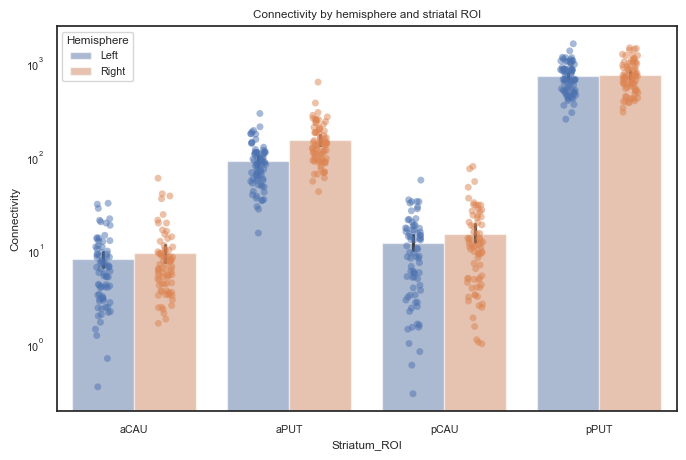

In [364]:
df_collapsed = long_df.groupby(["participant_id", 'Striatum_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and striatal ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

### Rostral–caudal

In [365]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_ROI']).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Rostral_Caudal,614.8950,1.0000,75.0000,0.0000
hemisphere,6.7448,1.0000,75.0000,0.0113
Cortex_ROI,331.4317,4.0000,300.0000,0.0000
Rostral_Caudal:hemisphere,1.1004,1.0000,75.0000,0.2976
Rostral_Caudal:Cortex_ROI,220.5020,4.0000,300.0000,0.0000
hemisphere:Cortex_ROI,49.9672,4.0000,300.0000,0.0000
Rostral_Caudal:hemisphere:Cortex_ROI,43.0023,4.0000,300.0000,0.0000


In [366]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere,-,Left,Right,-2.597068,75.0,1.131018e-02,NaN,2.868
1,Rostral_Caudal,-,Caudal,Rostral,24.797077,75.0,7.042100e-38,NaN,3.2e+34
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,22.026555,75.0,1.762526e-34,3.525053e-34,1.458e+31
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,20.621357,75.0,1.238338e-32,1.238338e-32,2.236e+29


In [367]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Rostral_Caudal', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Rostral_Caudal', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Rostral_Caudal,A,B,T,dof,p_unc,p_corr,BF10
0,Rostral_Caudal,-,Caudal,Rostral,24.797077,75.0,7.042100e-38,NaN,3.2e+34
1,hemisphere,-,Left,Right,-2.597068,75.0,1.131018e-02,NaN,2.868
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,-0.980320,75.0,3.300802e-01,3.300802e-01,0.2
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,-6.958239,75.0,1.111800e-09,2.223601e-09,9.582e+06


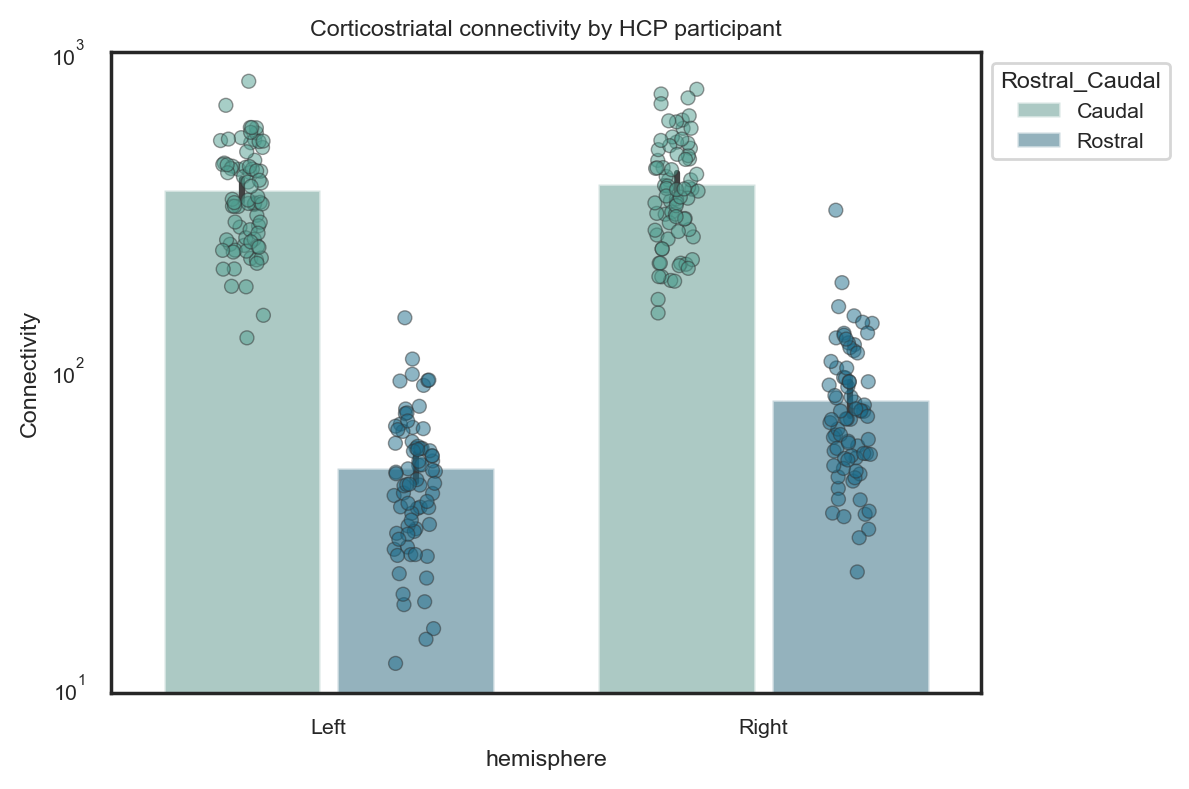

In [368]:
df_collapsed = long_df.groupby(["participant_id", 'hemisphere', 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=200)

sns.barplot(data=df_collapsed, 
              x='hemisphere', y='Connectivity', 
              hue='Rostral_Caudal', #hue_order=['early', 'middle', 'final'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.5, gap=0.1, #fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='hemisphere', y='Connectivity', 
              hue='Rostral_Caudal', #hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.5,
              alpha=0.5,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()


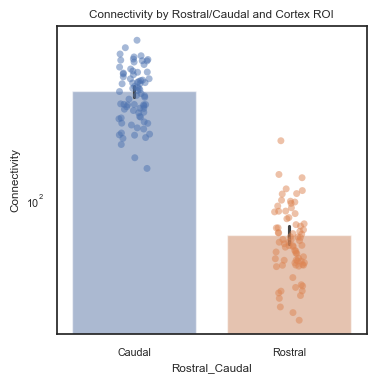

In [369]:
df_collapsed = long_df.groupby(["participant_id", 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(4, 4))
sns.barplot(x='Rostral_Caudal', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5)
sns.stripplot(x='Rostral_Caudal', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5)

plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

In [370]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-7.983099,75.0,1.284965e-11,1.427739e-11,6.945e+08
1,Cortex_ROI,-,HG,PT,5.342264,75.0,9.490934e-07,9.490934e-07,1.564e+04
2,Cortex_ROI,-,HG,STGa,24.328229,75.0,2.521094e-37,1.260547e-36,9.127e+33
3,Cortex_ROI,-,HG,STGp,19.104528,75.0,1.542922e-30,3.085844e-30,1.958e+27
4,Cortex_ROI,-,PP,PT,10.757955,75.0,7.355959e-17,9.194949e-17,8.257e+13
5,Cortex_ROI,-,PP,STGa,24.519564,75.0,1.494686e-37,1.260547e-36,1.526e+34
6,Cortex_ROI,-,PP,STGp,21.360978,75.0,1.287963e-33,4.293210e-33,2.066e+30
7,Cortex_ROI,-,PT,STGa,19.822149,75.0,1.525008e-31,3.812519e-31,1.899e+28
8,Cortex_ROI,-,PT,STGp,15.833748,75.0,1.264369e-25,2.107281e-25,2.978e+22
9,Cortex_ROI,-,STGa,STGp,-14.769301,75.0,6.685393e-24,9.550561e-24,6.124e+20


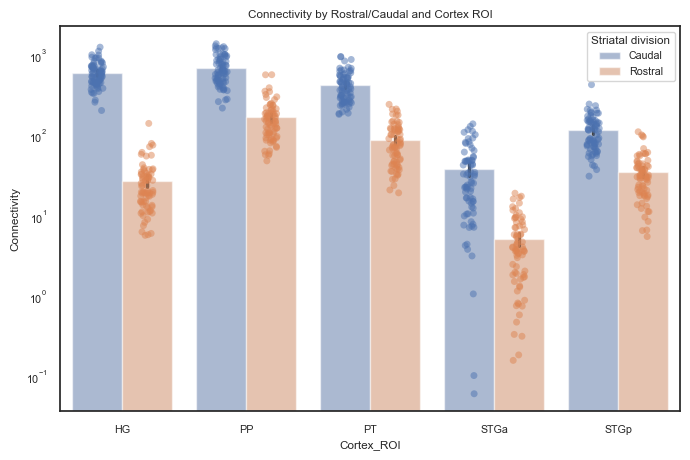

In [371]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Striatal division') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [372]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-7.983099,75.0,1.284965e-11,1.427739e-11,6.945e+08
1,Cortex_ROI,-,HG,PT,5.342264,75.0,9.490934e-07,9.490934e-07,1.564e+04
2,Cortex_ROI,-,HG,STGa,24.328229,75.0,2.521094e-37,1.260547e-36,9.127e+33
3,Cortex_ROI,-,HG,STGp,19.104528,75.0,1.542922e-30,3.085844e-30,1.958e+27
4,Cortex_ROI,-,PP,PT,10.757955,75.0,7.355959e-17,9.194949e-17,8.257e+13
5,Cortex_ROI,-,PP,STGa,24.519564,75.0,1.494686e-37,1.260547e-36,1.526e+34
6,Cortex_ROI,-,PP,STGp,21.360978,75.0,1.287963e-33,4.293210e-33,2.066e+30
7,Cortex_ROI,-,PT,STGa,19.822149,75.0,1.525008e-31,3.812519e-31,1.899e+28
8,Cortex_ROI,-,PT,STGp,15.833748,75.0,1.264369e-25,2.107281e-25,2.978e+22
9,Cortex_ROI,-,STGa,STGp,-14.769301,75.0,6.685393e-24,9.550561e-24,6.124e+20


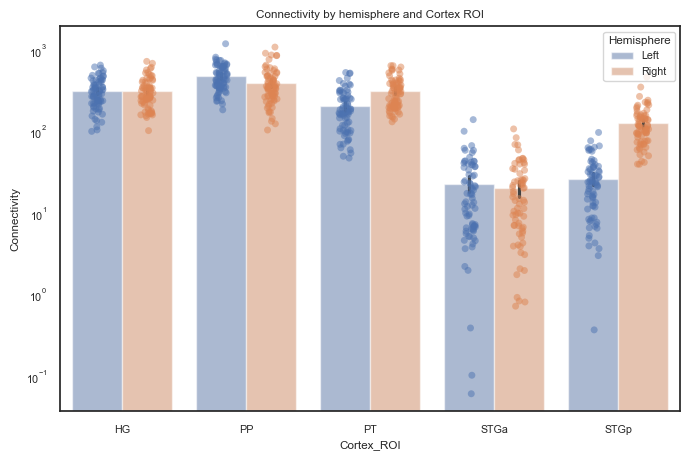

In [373]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and Cortex ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [374]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise)

Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


/Users/dsj3886/miniconda3/envs/py24/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7321: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,Contrast,Striatum_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Striatum_ROI,-,aCAU,aPUT,-16.670575,75.0,6.177606e-27,9.266409e-27,5.734e+23
1,Striatum_ROI,-,aCAU,pCAU,-5.166962,75.0,1.902862e-06,1.902862e-06,8125.525
2,Striatum_ROI,-,aCAU,pPUT,-26.840700,75.0,3.359273e-40,1.229439e-39,6.15e+36
3,Striatum_ROI,-,aPUT,pCAU,15.354279,75.0,7.418905e-25,8.902687e-25,5.266e+21
4,Striatum_ROI,-,aPUT,pPUT,-24.800509,75.0,6.977138e-38,1.395428e-37,3.229e+34
5,Striatum_ROI,-,pCAU,pPUT,-26.762344,75.0,4.098129e-40,1.229439e-39,5.057e+36
6,hemisphere,-,Left,Right,-2.597068,75.0,1.131018e-02,NaN,2.868
7,Striatum_ROI * hemisphere,aCAU,Left,Right,-1.079367,75.0,2.838834e-01,3.684231e-01,0.221
8,Striatum_ROI * hemisphere,aPUT,Left,Right,-7.102354,75.0,5.967026e-10,2.386811e-09,1.739e+07
9,Striatum_ROI * hemisphere,pCAU,Left,Right,-1.611817,75.0,1.112023e-01,2.224046e-01,0.434


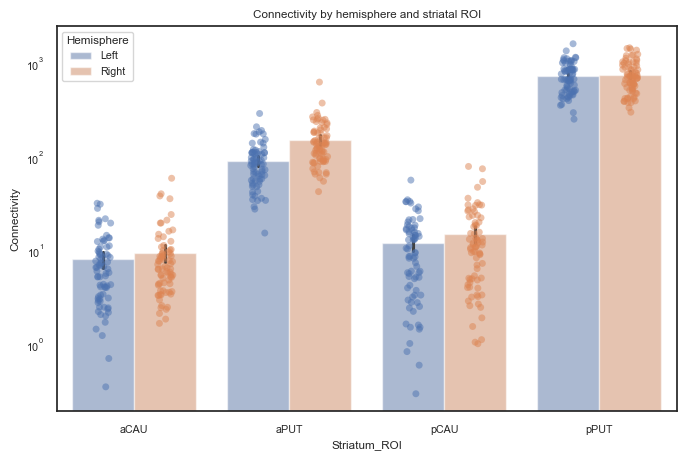

In [375]:
df_collapsed = long_df.groupby(["participant_id", 'Striatum_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and striatal ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

### Auditory vs. Prefrontal

In [376]:
auditory_rois   = ['HG', 'PP', 'PT', 'STGa', 'STGp']
prefrontal_rois = ['FP', 'SFG', 'MFG', 'IFGt', 'IFGo',
                   'PreCG', 'FMC', 'PCG', 'ACC', 'OFC', 'FO']

category_map = {r: 'Auditory'   for r in auditory_rois}
category_map.update({r: 'Prefrontal' for r in prefrontal_rois})

aud_pfc_df = all_long_df[all_long_df['Cortex_ROI'].isin(auditory_rois + prefrontal_rois)].copy()
aud_pfc_df['Cortex_Category'] = aud_pfc_df['Cortex_ROI'].map(category_map)

In [377]:
aov = AnovaRM(aud_pfc_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Cortex_Category', 'Caudate_Putamen']).fit()
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Cortex_Category,908.3989,1.0000,75.0000,0.0000
Caudate_Putamen,902.9261,1.0000,75.0000,0.0000
Cortex_Category:Caudate_Putamen,94.6052,1.0000,75.0000,0.0000


In [382]:
pairwise = pg.pairwise_tests(data=aud_pfc_df,
                             dv='Connectivity',
                             within=['Cortex_Category', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr')
pairwise[['Contrast', 'Cortex_Category', 'A', 'B', 'T', 'dof', 'p_unc', 'BF10']]

,Contrast,Cortex_Category,A,B,T,dof,p_unc,BF10
0,Cortex_Category,-,Auditory,Prefrontal,-30.139656,75.0,1.167233e-43,1.562e+40
1,Caudate_Putamen,-,Caudate,Putamen,-30.048730,75.0,1.439268e-43,1.271e+40
2,Cortex_Category * Caudate_Putamen,Auditory,Caudate,Putamen,-27.217270,75.0,1.300610e-40,1.565e+37
3,Cortex_Category * Caudate_Putamen,Prefrontal,Caudate,Putamen,-21.871618,75.0,2.789259e-34,9.288e+30


In [385]:
pairwise = pg.pairwise_tests(data=aud_pfc_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Cortex_Category'],
                             subject='participant_id',
                             padjust='fdr')
pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'T', 'dof', 'p_unc', 'BF10']]

,Contrast,Caudate_Putamen,A,B,T,dof,p_unc,BF10
0,Caudate_Putamen,-,Caudate,Putamen,-30.048730,75.0,1.439268e-43,1.271e+40
1,Cortex_Category,-,Auditory,Prefrontal,-30.139656,75.0,1.167233e-43,1.562e+40
2,Caudate_Putamen * Cortex_Category,Caudate,Auditory,Prefrontal,-21.488011,75.0,8.781050e-34,3.01e+30
3,Caudate_Putamen * Cortex_Category,Putamen,Auditory,Prefrontal,-30.285988,75.0,8.341053e-44,2.174e+40


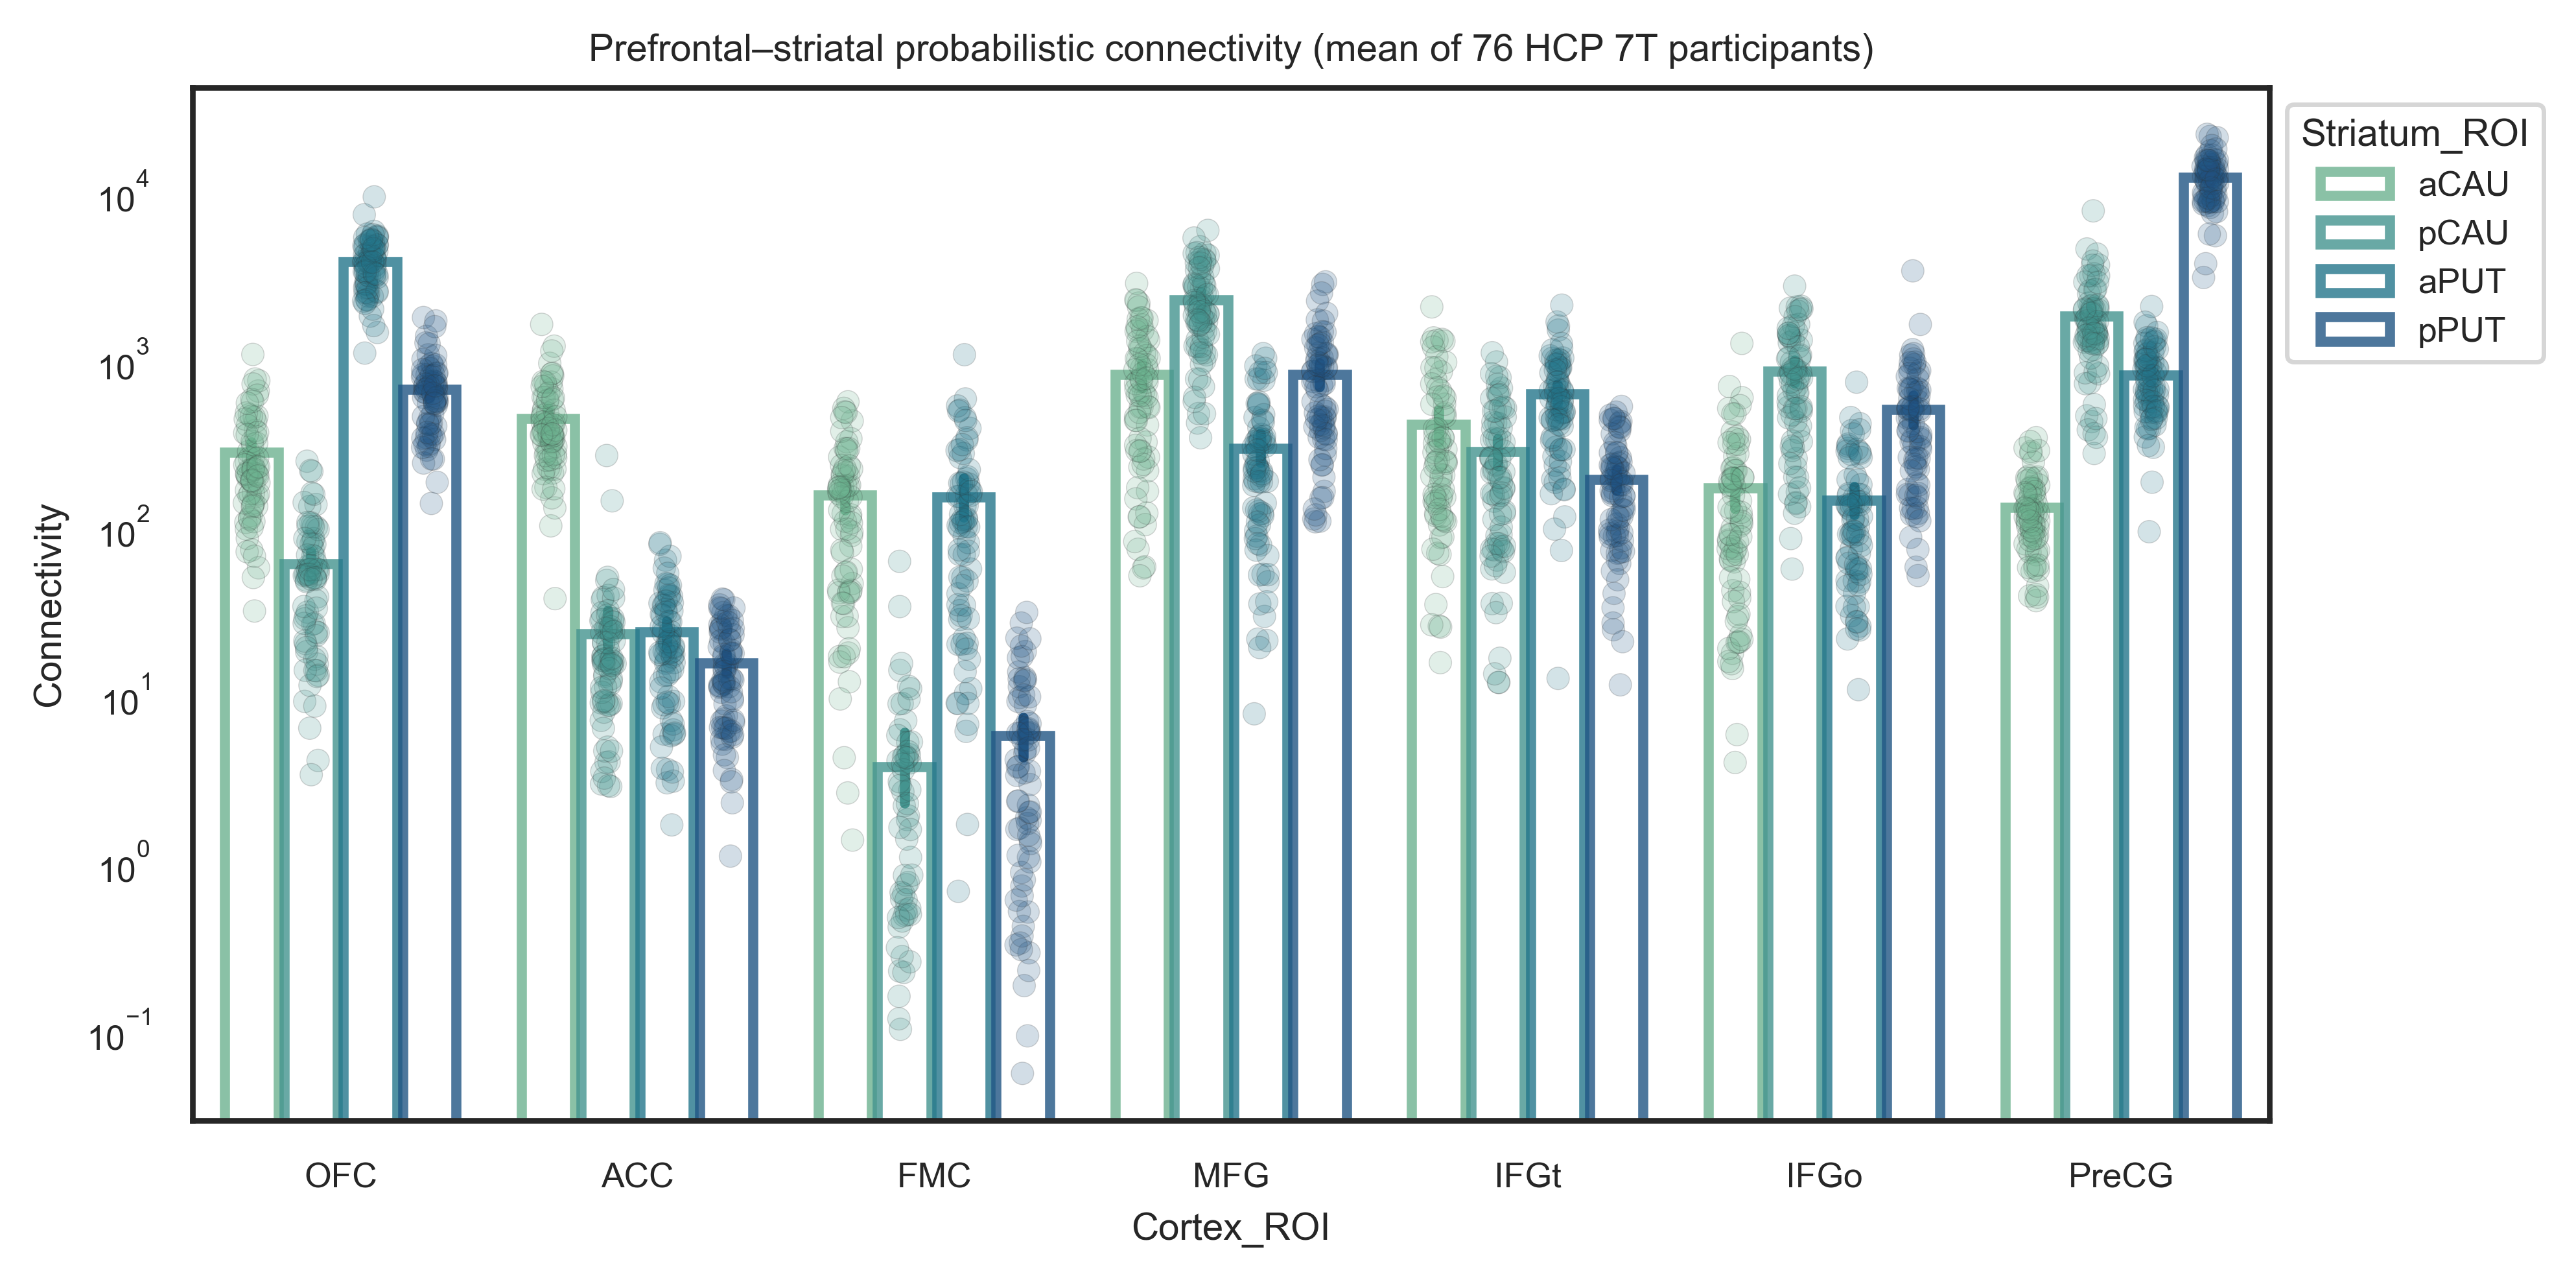

In [ ]:
pfc_df = aud_pfc_df[aud_pfc_df['Cortex_Category'] == 'Prefrontal']
pfc_df = pfc_df[pfc_df['Cortex_ROI'].isin(PREFRONTAL_ROIS)]

df_collapsed_pfc = pfc_df.groupby(['participant_id', 'Cortex_ROI', 'Striatum_ROI'],
                                   as_index=False).agg({'Connectivity': 'mean'})

fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=500)

sns.barplot(data=df_collapsed_pfc,
            x='Cortex_ROI', y='Connectivity',
            order=PREFRONTAL_ROIS,
            hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
            palette='crest',
            alpha=0.8, gap=0.1, fill=False,
            ax=ax)
sns.stripplot(data=df_collapsed_pfc,
              x='Cortex_ROI', y='Connectivity',
              order=PREFRONTAL_ROIS,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True, jitter=True,
              linewidth=0.2, alpha=0.2,
              legend=None,
              ax=ax)

sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))
ax.set_title(f'Prefrontal–striatal probabilistic connectivity (mean of {num_participants} HCP 7T participants)')
plt.yscale('log')

fig.savefig('streamline-count_x-prefrontal_hue-striatum.svg')
fig.tight_layout()


## Anatomical Connectivity Figure (Yeterian & Pandya 1998 Style)

Schematic figure showing auditory corticostriatal connectivity on a lateral brain view and coronal striatal cross-sections.


In [403]:
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import PathPatch, FancyArrowPatch
from matplotlib.path import Path
import matplotlib.patches as mpatches
import nibabel as nib
from skimage import measure
import seaborn as sns

In [404]:
# ── Placeholder paths — update before running ─────────────────────────────────
atlas_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal/')
file_prefix = 'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal'

BRAIN_MASK_PATH = os.path.join('/Users/dsj3886/data_local/reference/',
                               'mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/',
                               'mni_icbm152_t1_tal_nlin_asym_09c_mask.nii')

AUDITORY_MASK_PATHS = {
    "HG":   os.path.join(atlas_dir, f'{file_prefix}_L-HG.nii.gz'),
    "PP":   os.path.join(atlas_dir, f'{file_prefix}_L-PP.nii.gz'),
    "PT":   os.path.join(atlas_dir, f'{file_prefix}_L-PT.nii.gz'),
    "STGa": os.path.join(atlas_dir, f'{file_prefix}_L-STGa.nii.gz'),
    "STGp": os.path.join(atlas_dir, f'{file_prefix}_L-STGp.nii.gz'),
}

PREFRONTAL_MASK_PATHS = {
    "OFC":   os.path.join(atlas_dir, f'{file_prefix}_L-OFC.nii.gz'),
    "ACC":   os.path.join(atlas_dir, f'{file_prefix}_L-ACC.nii.gz'),
    "FMC":   os.path.join(atlas_dir, f'{file_prefix}_L-FMC.nii.gz'),
    "MFG":   os.path.join(atlas_dir, f'{file_prefix}_L-MFG.nii.gz'),
    "IFGt":  os.path.join(atlas_dir, f'{file_prefix}_L-IFGt.nii.gz'),
    "IFGo":  os.path.join(atlas_dir, f'{file_prefix}_L-IFGo.nii.gz'),
    "PreCG": os.path.join(atlas_dir, f'{file_prefix}_L-PreCG.nii.gz'),
}

STRIATAL_MASK_PATHS = {
    "aPUT": os.path.join(atlas_dir, f'{file_prefix}_aPUT-lh.nii.gz'),
    "pPUT": os.path.join(atlas_dir, f'{file_prefix}_pPUT-lh.nii.gz'),
    "aCAU": os.path.join(atlas_dir, f'{file_prefix}_aCAU-lh.nii.gz'),
    "pCAU": os.path.join(atlas_dir, f'{file_prefix}_pCAU-lh.nii.gz'),
}


In [405]:
def get_roi_contour(mask_path, axis=1, slice_idx=None):
    """
    Load a binary NIfTI mask and return the largest 2D contour from a slice.

    axis=0 -> sagittal slice
    axis=1 -> coronal slice
    slice_idx: if None, use the slice with the largest cross-sectional area.
    """
    data = nib.load(mask_path).get_fdata()
    if slice_idx is None:
        areas = [np.take(data, i, axis=axis).sum() for i in range(data.shape[axis])]
        slice_idx = int(np.argmax(areas))
    slice_2d = np.take(data, slice_idx, axis=axis)
    contours = measure.find_contours(slice_2d, level=0.5)
    return max(contours, key=len)


def get_best_slice_idx(mask_path, axis):
    """Return the slice index with the largest mask area along the given axis."""
    data = nib.load(mask_path).get_fdata()
    areas = [np.take(data, i, axis=axis).sum() for i in range(data.shape[axis])]
    return int(np.argmax(areas))


In [406]:
# ── Data preparation (all cortical ROIs) ──────────────────────────────────────
AUDITORY_ROIS   = ['STGa', 'PP', 'HG', 'PT', 'STGp']
PREFRONTAL_ROIS = ['OFC', 'ACC', 'FMC', 'MFG', 'IFGt', 'IFGo', 'PreCG']
CORTEX_ROIS     = AUDITORY_ROIS + PREFRONTAL_ROIS
CORTEX_ROI      = 'HG'   # highlighted in the brain panel

all_conn = (
    all_long_df[all_long_df['Cortex_ROI'].isin(CORTEX_ROIS)]
    .groupby(['Cortex_ROI', 'Striatum_ROI'])['Connectivity']
    .mean()
    .reset_index()
    .rename(columns={'Connectivity': 'conn_mean'})
)
print(all_conn)


   Cortex_ROI Striatum_ROI     conn_mean
0         ACC         aCAU    446.667387
1         ACC         aPUT     23.776086
2         ACC         pCAU     23.261653
3         ACC         pPUT     15.531474
4         FMC         aCAU    155.766903
5         FMC         aPUT    151.374684
6         FMC         pCAU      3.740185
7         FMC         pPUT      5.752613
8          HG         aCAU      2.618567
9          HG         aPUT     51.953103
10         HG         pCAU      4.590984
11         HG         pPUT   1203.405786
12       IFGo         aCAU    172.314811
13       IFGo         aPUT    144.795436
14       IFGo         pCAU    854.742322
15       IFGo         pPUT    504.599187
16       IFGt         aCAU    411.226153
17       IFGt         aPUT    627.790149
18       IFGt         pCAU    282.730333
19       IFGt         pPUT    192.620436
20        MFG         aCAU    818.508474
21        MFG         aPUT    296.486734
22        MFG         pCAU   2277.655231
23        MFG   

In [407]:
from matplotlib.colors import Normalize as MplNorm, LogNorm, to_rgb
from matplotlib.cm import ScalarMappable

CMAP = plt.cm.YlOrRd

AUDITORY_PALETTE = {
    'HG':   CMAP(0.85),
    'PP':   '#5aafe0',
    'PT':   '#78c679',
    'STGa': '#9970ab',
    'STGp': '#d9a63a',
}

PREFRONTAL_PALETTE = {
    'OFC':   '#e8a838',
    'ACC':   '#d46b6b',
    'FMC':   '#8e5fbf',
    'MFG':   '#4d9de0',
    'IFGt':  '#3bb273',
    'IFGo':  '#e84855',
    'PreCG': '#7f8c8d',
}

# Paint order: last = highest priority (drawn on top).
# Auditory (temporal plane) are given priority over prefrontal.
PAINT_ORDER = ['PreCG', 'IFGo', 'IFGt', 'MFG', 'FMC', 'ACC', 'OFC',
               'STGp', 'STGa', 'PT', 'PP', 'HG']

# Z-shear applied before Y-Z projection.
# Positive value: each voxel at X=x is shifted +x*SHEAR_FACTOR in Z.
# This tilts the projection to look from slightly below, separating the
# superior temporal plane (HG/PP/PT, deeper/more medial) from the lateral
# surface (STGa/STGp, more lateral).
SHEAR_FACTOR = 0.3


def _sheared_footprint(mask_3d, shear_factor, out_nz):
    """Y-Z footprint with Z-shear. Returns bool array (ny, out_nz)."""
    nx, ny, nz = mask_3d.shape
    result = np.zeros((ny, out_nz), dtype=bool)
    for x in range(nx):
        z_shift = int(round(x * shear_factor))
        sl = mask_3d[x] > 0          # (ny, nz)
        src_end = min(nz, out_nz - z_shift)
        dst_start = z_shift
        if src_end > 0 and dst_start < out_nz:
            result[:, dst_start:dst_start + src_end] |= sl[:, :src_end]
    return result


def _make_surface_rgba(brain_mask_path, roi_mask_paths, palette):
    """
    Sheared Y-Z footprint per ROI painted in PAINT_ORDER.
    Returns (rgba (nz_out,ny,4), brain_proj (ny,nz_out), roi_label (ny,nz_out), roi_list).
    """
    brain_data = nib.load(brain_mask_path).get_fdata() > 0
    nx, ny, nz = brain_data.shape
    nz_out = nz + int(nx * SHEAR_FACTOR) + 2   # extra Z room after shearing

    brain_proj = _sheared_footprint(brain_data, SHEAR_FACTOR, nz_out)

    footprints = {
        roi: _sheared_footprint(nib.load(path).get_fdata(), SHEAR_FACTOR, nz_out)
        for roi, path in roi_mask_paths.items()
    }

    rgba = np.zeros((nz_out, ny, 4), dtype=float)
    in_brain = brain_proj.T
    rgba[in_brain, :3] = 0.85
    rgba[in_brain,  3] = 1.0

    roi_list  = list(roi_mask_paths.keys())
    roi_label = np.zeros((ny, nz_out), dtype=int)

    for roi in PAINT_ORDER:
        if roi not in footprints:
            continue
        fp   = footprints[roi]
        mask = fp.T
        rgba[mask, :3] = to_rgb(palette.get(roi, '#888888'))
        rgba[mask,  3] = 1.0
        roi_label[fp] = roi_list.index(roi) + 1

    rgba[~in_brain, 3] = 0.0
    return rgba, brain_proj, roi_label, roi_list, footprints


def draw_brain_panel(ax, brain_mask_path, cortex_mask_paths, striatal_mask_paths):
    combined_palette = {**AUDITORY_PALETTE, **PREFRONTAL_PALETTE}
    rgba, brain_proj, roi_label, roi_list, footprints = _make_surface_rgba(
        brain_mask_path, cortex_mask_paths, combined_palette)

    ny, nz_out = brain_proj.shape
    ax.imshow(rgba, origin='lower', extent=[0, ny, 0, nz_out],
              aspect='equal', interpolation='nearest')

    # Brain silhouette
    brain_contour = max(measure.find_contours(brain_proj.astype(float), level=0.5), key=len)
    ax.plot(brain_contour[:, 0], brain_contour[:, 1], color='black', linewidth=1.5, zorder=4)

    # ROI boundary contours
    for roi, fp in footprints.items():
        contours = measure.find_contours(fp.astype(float), level=0.5)
        for c in contours:
            ax.plot(c[:, 0], c[:, 1], color='black', linewidth=0.6, zorder=5)

    # Labels at painted centroid
    for idx, roi in enumerate(roi_list, start=1):
        ys, zs = np.where(roi_label == idx)
        if len(ys) == 0:
            continue
        is_active = (roi == CORTEX_ROI)
        ax.text(ys.mean(), zs.mean(), roi,
                ha='center', va='center', fontsize=7, zorder=6,
                fontweight='bold' if is_active else 'normal',
                color='white' if is_active else 'black')

    # Crop to brain bounding box
    ys, zs = np.where(brain_proj)
    margin = 4
    ax.set_xlim(ys.min() - margin, ys.max() + margin)
    ax.set_ylim(zs.min() - margin, zs.max() + margin)
    ax.set_aspect('equal')
    ax.invert_xaxis()

    ax.axis('off')


def draw_striatal_structure(ax, roi_ant, roi_post, hg_conn_df, striatal_mask_paths, norm, title=None):
    data_ant  = nib.load(striatal_mask_paths[roi_ant]).get_fdata()
    data_post = nib.load(striatal_mask_paths[roi_post]).get_fdata()
    slice_idx = int(np.argmax((data_ant + data_post).sum(axis=(1, 2))))

    for roi, data in [(roi_ant, data_ant), (roi_post, data_post)]:
        row      = hg_conn_df[hg_conn_df["Striatum_ROI"] == roi]
        conn_val = float(row["conn_mean"].values[0]) if not row.empty else 0
        contours = measure.find_contours(data[slice_idx, :, :], level=0.5)
        if not contours:
            continue
        contour = max(contours, key=len)
        verts = np.column_stack([contour[:, 0], contour[:, 1]])
        codes  = [Path.MOVETO] + [Path.LINETO] * (len(verts) - 2) + [Path.CLOSEPOLY]
        ax.add_patch(PathPatch(Path(verts, codes),
                               facecolor=CMAP(norm(conn_val)),
                               edgecolor='black', linewidth=1.5))
        label = 'ant' if roi == roi_ant else 'post'
        ax.text(np.mean(contour[:, 0]), np.mean(contour[:, 1]), label,
                ha='center', va='center', fontsize=6, color='black', alpha=0.7)

    if title:
        ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')
    ax.autoscale()
    # Tighten limits to the data so no internal whitespace inflates the gap
    margin = 3
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.invert_xaxis()
    ax.axis('off')


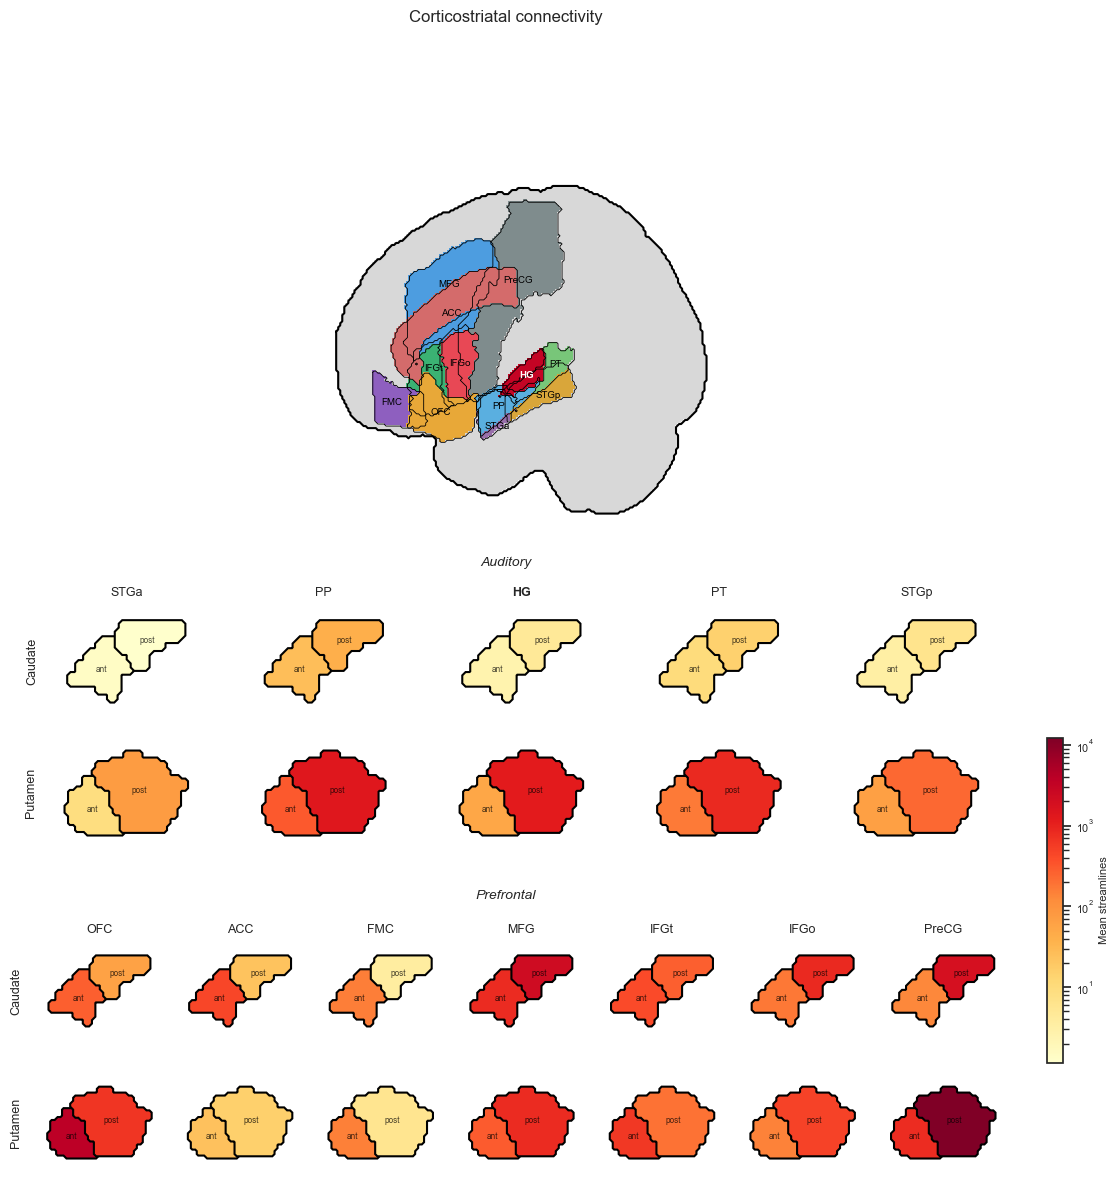

In [450]:
# -- Build figure: brain top, auditory middle, prefrontal bottom --------------
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

vmax     = float(all_conn['conn_mean'].max())
vmin_log = max(float(all_conn['conn_mean'].min()), 1)
norm     = LogNorm(vmin=vmin_log, vmax=vmax)

col_w = 1.8
fig_w = col_w * max(len(AUDITORY_ROIS), len(PREFRONTAL_ROIS))
fig   = plt.figure(figsize=(fig_w, 13))

# Outer grid: brain | auditory (cau+put) | prefrontal (cau+put)
gs_outer = gridspec.GridSpec(3, 1, height_ratios=[2.5, 1.8, 1.8], hspace=0.3)

ax_brain = fig.add_subplot(gs_outer[0])
draw_brain_panel(ax_brain, BRAIN_MASK_PATH, {**AUDITORY_MASK_PATHS, **PREFRONTAL_MASK_PATHS}, STRIATAL_MASK_PATHS)

# ── Auditory section ─────────────────────────────────────────────────────────
gs_aud = gridspec.GridSpecFromSubplotSpec(
    2, len(AUDITORY_ROIS), subplot_spec=gs_outer[1], wspace=0.06, hspace=0.15)

ax_cau_aud_first = ax_put_aud_first = None
for col, roi in enumerate(AUDITORY_ROIS):
    conn_df = all_conn[all_conn['Cortex_ROI'] == roi]
    ax_cau = fig.add_subplot(gs_aud[0, col])
    ax_put = fig.add_subplot(gs_aud[1, col])
    if col == 0:
        ax_cau_aud_first = ax_cau
        ax_put_aud_first = ax_put
    draw_striatal_structure(ax_cau, 'aCAU', 'pCAU', conn_df, STRIATAL_MASK_PATHS, norm)
    draw_striatal_structure(ax_put, 'aPUT', 'pPUT', conn_df, STRIATAL_MASK_PATHS, norm)
    ax_cau.set_title(roi, fontsize=9, fontweight='bold' if roi == CORTEX_ROI else 'normal')

ax_cau_aud_first.annotate('Caudate', xy=(0, 0.5), xycoords='axes fraction',
                           xytext=(-8, 0), textcoords='offset points',
                           ha='right', va='center', fontsize=9, rotation=90)
ax_put_aud_first.annotate('Putamen', xy=(0, 0.5), xycoords='axes fraction',
                           xytext=(-8, 0), textcoords='offset points',
                           ha='right', va='center', fontsize=9, rotation=90)

# ── Prefrontal section ───────────────────────────────────────────────────────
gs_pfc = gridspec.GridSpecFromSubplotSpec(
    2, len(PREFRONTAL_ROIS), subplot_spec=gs_outer[2], wspace=0.06, hspace=0.15)

ax_cau_pfc_first = ax_put_pfc_first = None
for col, roi in enumerate(PREFRONTAL_ROIS):
    conn_df = all_conn[all_conn['Cortex_ROI'] == roi]
    ax_cau = fig.add_subplot(gs_pfc[0, col])
    ax_put = fig.add_subplot(gs_pfc[1, col])
    if col == 0:
        ax_cau_pfc_first = ax_cau
        ax_put_pfc_first = ax_put
    draw_striatal_structure(ax_cau, 'aCAU', 'pCAU', conn_df, STRIATAL_MASK_PATHS, norm)
    draw_striatal_structure(ax_put, 'aPUT', 'pPUT', conn_df, STRIATAL_MASK_PATHS, norm)
    ax_cau.set_title(roi, fontsize=9)

ax_cau_pfc_first.annotate('Caudate', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)
ax_put_pfc_first.annotate('Putamen', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)

# ── Section labels: placed in the hspace gap between outer rows ──────────────
fig.canvas.draw()
# midpoint of gap between brain bottom and auditory caudate top
aud_label_y = (ax_cau_aud_first.get_position().y1 + ax_brain.get_position().y0) / 2
# midpoint of gap between auditory putamen bottom and prefrontal caudate top
pfc_label_y = (ax_cau_pfc_first.get_position().y1 + ax_put_aud_first.get_position().y0) / 2
fig.text(0.5, aud_label_y, 'Auditory',   ha='center', va='center', fontsize=10, style='italic')
fig.text(0.5, pfc_label_y, 'Prefrontal', ha='center', va='center', fontsize=10, style='italic')

# ── Shared colorbar ──────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.93, 0.2, 0.012, 0.25])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Mean streamlines', fontsize=8)

fig.suptitle('Corticostriatal connectivity', fontsize=12, y=1.01)

fig.savefig('corticostriatal_connectivity_schematic.pdf', bbox_inches='tight', dpi=300)
fig.savefig('corticostriatal_connectivity_schematic.png', bbox_inches='tight', dpi=300)
fig.savefig('corticostriatal_connectivity_schematic.svg', bbox_inches='tight', dpi=300)
plt.show()


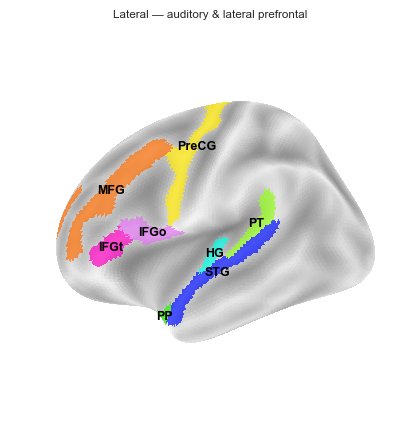

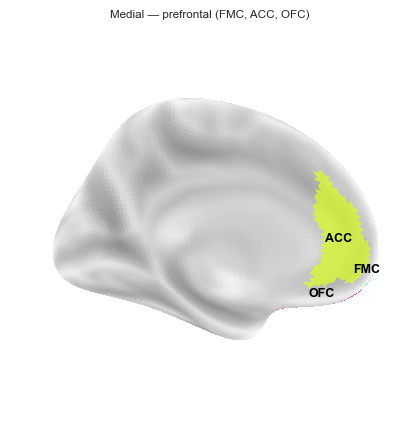

In [420]:
from nilearn import datasets, plotting, surface
import numpy as np

destrieux = datasets.fetch_atlas_surf_destrieux()
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')

labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux['labels']]
parc   = destrieux['map_left']
coords, _ = surface.load_surf_mesh(fsaverage['infl_left'])

# ROI → Destrieux label
auditory_destrieux = {
    'STG':  'G_temp_sup-Lateral',
    'HG':   'G_temp_sup-G_T_transv',
    'PP':   'G_temp_sup-Plan_polar',
    'PT':   'G_temp_sup-Plan_tempo',
}
lateral_pfc_destrieux = {
    'PreCG': 'G_precentral',
    'MFG':   'G_front_middle',
    'IFGt':  'G_front_inf-Triangul',
    'IFGo':  'G_front_inf-Opercular',
}
medial_pfc_destrieux = {
    'FMC': 'G_and_S_frontomargin',
    'ACC': 'G_and_S_cingul-Ant',
    'OFC': 'G_orbital',
}


def make_roi_map(roi_dict):
    roi_map = np.zeros(len(parc))
    for roi_id, label in enumerate(roi_dict.values(), start=1):
        idx = labels.index(label)
        roi_map[parc == idx] = roi_id
    return roi_map


def add_labels(ax, roi_map, roi_dict):
    for roi_id, name in enumerate(roi_dict.keys(), start=1):
        verts = np.where(roi_map == roi_id)[0]
        if len(verts) == 0:
            continue
        cx, cy, cz = coords[verts].mean(axis=0)
        ax.text(cx, cy, cz, name, fontsize=9, fontweight='bold',
                ha='center', va='center', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.))


# ── Lateral view: auditory + lateral prefrontal ───────────────────────────────
lateral_rois    = {**auditory_destrieux, **lateral_pfc_destrieux}
roi_map_lateral = make_roi_map(lateral_rois)

fig_lat = plotting.plot_surf_roi(
    fsaverage['infl_left'],
    roi_map=roi_map_lateral,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    view='lateral',
    title='Lateral — auditory & lateral prefrontal',
)
add_labels(fig_lat.axes[0], roi_map_lateral, lateral_rois)

# ── Medial view: medial/orbital prefrontal ────────────────────────────────────
roi_map_medial = make_roi_map(medial_pfc_destrieux)

fig_med = plotting.plot_surf_roi(
    fsaverage['infl_left'],
    roi_map=roi_map_medial,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    view='medial',
    title='Medial — prefrontal (FMC, ACC, OFC)',
)
add_labels(fig_med.axes[0], roi_map_medial, medial_pfc_destrieux)


In [414]:
import os 
atlas_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal/',
                           'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_atlas_space-MNI152NLin6Asym.nii.gz')

In [415]:
from nilearn._utils.helpers import is_plotly_installed

In [416]:
is_plotly_installed()

True

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from nilearn.plotting import view_img_on_surf
import nibabel as nib

# Keep subcortical (1-8), auditory (9-18), and selected prefrontal only.
# Zero out visual (41-54) and excluded prefrontal ROIs.
pfc_to_keep = {'L-' + r for r in PREFRONTAL_ROIS} | {'R-' + r for r in PREFRONTAL_ROIS}

atlas_img  = nib.load(atlas_fpath)
atlas_data = atlas_img.get_fdata().copy()
for label_idx, label_name in enumerate(region_list, start=1):
    if label_idx >= 41 or (19 <= label_idx <= 40 and label_name not in pfc_to_keep):
        atlas_data[atlas_data == label_idx] = 0

masked_img = nib.Nifti1Image(atlas_data.astype(np.float32), atlas_img.affine, atlas_img.header)
n_labels = int(atlas_data.max())

# Shuffled palette so adjacent label numbers don't share a hue family
_base = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
_rng  = np.random.default_rng(42)
_idx  = _rng.permutation(60)[:n_labels]
cmap_rois = ListedColormap([_base[i] for i in _idx])

view = view_img_on_surf(
    stat_map_img=masked_img,
    surf_mesh="fsaverage",
    threshold=0.5,
    cmap=cmap_rois,
    vmin=1,
    vmax=n_labels,
    vol_to_surf_kwargs={
        "n_samples": 1,
        "radius": 3,
        "interpolation": "nearest",
    },
    symmetric_cmap=False,
    colorbar=False,
)

view # CLEAR AFTER MANUAL SAVE - otherwise file gets too large
